In [1]:
from sklearn.datasets import make_regression
from helpers import *
from filters import *
from functools import partial


In [2]:
import numpy as np
preds = np.load('./preds_mcd_af.npy')
gts = np.load('./gts_mcd_af.npy')

gts_nAF = 1-gts
gts_AF = gts
preds_nAF = preds[:,0]
preds_AF = preds[:,1]

In [3]:
test_preds = np.load('<path>/checkpoints_af_mcd_sgd_0.001_1e-10_64_0.9_8_0.05/paper_results/03noise/test_preds/preds_mcd_af.npy')
test_gts = np.load('<path>/checkpoints_af_mcd_sgd_0.001_1e-10_64_0.9_8_0.05/paper_results/03noise/test_preds/gts_mcd_af.npy')

In [4]:
test_noise_preds = np.load('<path>/checkpoints_af_mcd_sgd_0.001_1e-10_64_0.9_8_0.05/paper_results/03noise/noise_preds/preds_mcd_af.npy')
test_noise_gts = np.load('<path>/checkpoints_af_mcd_sgd_0.001_1e-10_64_0.9_8_0.05/paper_results/03noise/noise_preds/gts_mcd_af.npy')

In [5]:
test_preds_AF = test_preds[:,1]
intervals = []
for i,pred in enumerate(test_preds_AF):
    #print(i/15377)
    intervals.append(predict_interval(pred,preds_AF,gts_AF))

In [6]:
test_noise_preds_AF = test_noise_preds[:,1]
intervals_noise = []
for i,pred in enumerate(test_noise_preds_AF):
    #print(i/15377)
    intervals_noise.append(predict_interval(pred,preds_AF,gts_AF))

# DTT

## Retain only

### Original test set

/tmp/ipykernel_4173255/4031105318.py:98: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  aurc_mag = np.trapz(risks_mag_filtered, retain_fractions)
/tmp/ipykernel_4173255/4031105318.py:99: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  aurc_ec = np.trapz(risks_ec_filtered, retain_fractions)
/tmp/ipykernel_4173255/4031105318.py:101: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  aucc_mag = np.trapz(expected_costs_mag_filtered, retain_fractions)
/tmp/ipykernel_4173255/4031105318.py:102: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  aucc_ec = np.trapz(expected_costs_ec_filtered, retain_fractions)


AURC naive rule:      0.1115$
AURC cost-aware rule: 0.1098$

AUCC naive rule:      458.6814$
AUCC cost-aware rule: 442.6533$


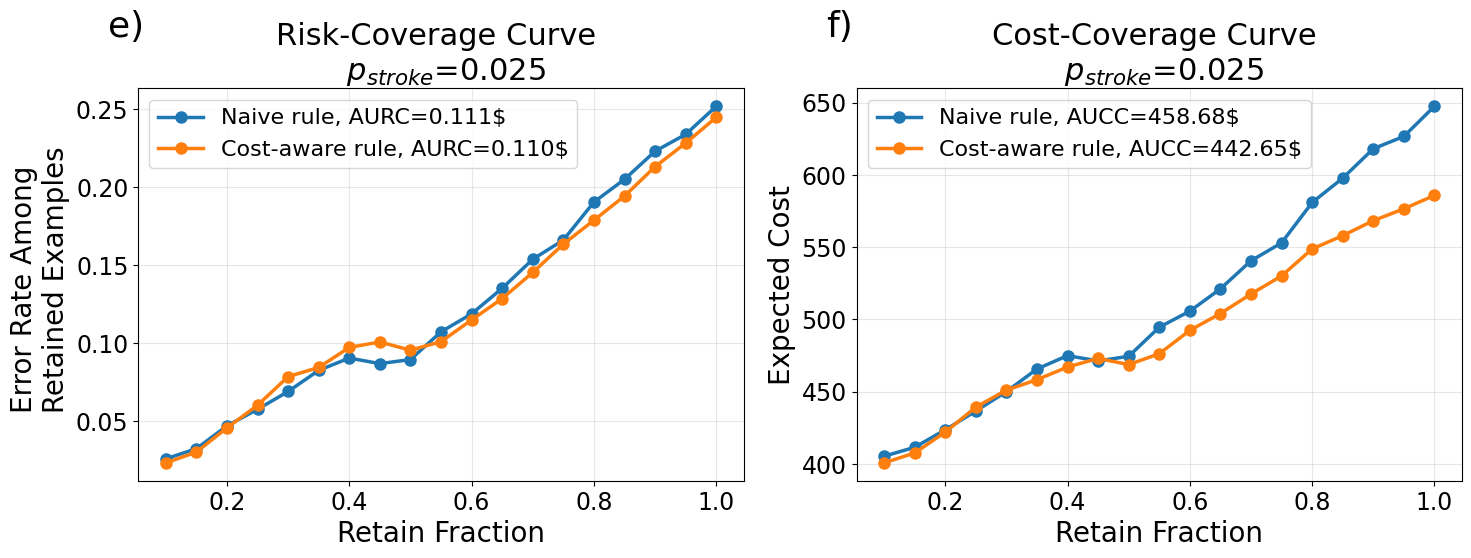

In [7]:
# ------------------------------------------------------------
# Plot risk-coverage and cost-coverage curves
# ------------------------------------------------------------

import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Risk-coverage / cost-coverage analysis
# ------------------------------------------------------------

retain_fractions = np.linspace(0.1, 1.0, 19)

risks_mag_filtered = []
risks_ec_filtered = []

expected_costs_mag_filtered = []
expected_costs_ec_filtered = []
cost_fn = partial(compute_single_prediction_cost,p_stroke_missed_af=0.025)

for rf in retain_fractions:

    # --------------------------------------------------------
    # Naive rule: retain by probability magnitude / confidence
    # --------------------------------------------------------
    out_mag_filtered = evaluate_va_prob_magnitude_filtering(
        intervals=np.squeeze(intervals),
        y_true=test_gts,
        retain_fraction=rf,
        pred_method="collapse",
    )

    remaining_probs_mag = out_mag_filtered["arrays"]["retained_p_hat"]
    remaining_gts_mag = out_mag_filtered["arrays"]["retained_y_true"]

    remaining_preds_mag = (remaining_probs_mag >= 0.5).astype(int)

    risk_mag = np.mean(remaining_preds_mag != remaining_gts_mag)
    risks_mag_filtered.append(risk_mag)

    cost_mag = compute_af_screening_cost(
        preds_AF,
        gts_AF,
        remaining_probs_mag,
        remaining_gts_mag,
        p_stroke_missed_af=.025,
    )["expected_cost"]

    expected_costs_mag_filtered.append(cost_mag)

    # --------------------------------------------------------
    # Cost-aware rule: reject by expected decision cost
    # --------------------------------------------------------
    out_ec_filtered = evaluate_va_expected_cost_filtering(
        intervals=np.squeeze(intervals),
        y_true=test_gts,
        cost_fn=cost_fn,
        threshold=0.381,
        reject_fraction=1 - rf,
        pred_method="collapse",
    )

    remaining_probs_ec = out_ec_filtered["arrays"]["retained_p_hat"]
    remaining_gts_ec = out_ec_filtered["arrays"]["retained_y_true"]

    remaining_preds_ec = (remaining_probs_ec >= 0.381).astype(int)

    risk_ec = np.mean(remaining_preds_ec != remaining_gts_ec)
    risks_ec_filtered.append(risk_ec)

    cost_ec = compute_af_screening_cost(
        preds_AF,
        gts_AF,
        remaining_probs_ec,
        remaining_gts_ec,
        p_stroke_missed_af=.025,
        threshold = .381,
    )["expected_cost"]

    expected_costs_ec_filtered.append(cost_ec)


# ------------------------------------------------------------
# Convert to arrays
# ------------------------------------------------------------

risks_mag_filtered = np.asarray(risks_mag_filtered)
risks_ec_filtered = np.asarray(risks_ec_filtered)

expected_costs_mag_filtered = np.asarray(expected_costs_mag_filtered)
expected_costs_ec_filtered = np.asarray(expected_costs_ec_filtered)


# ------------------------------------------------------------
# Compute summary metrics
# ------------------------------------------------------------

aurc_mag = np.trapz(risks_mag_filtered, retain_fractions)
aurc_ec = np.trapz(risks_ec_filtered, retain_fractions)

aucc_mag = np.trapz(expected_costs_mag_filtered, retain_fractions)
aucc_ec = np.trapz(expected_costs_ec_filtered, retain_fractions)

print(f"AURC naive rule:      {aurc_mag:.4f}$")
print(f"AURC cost-aware rule: {aurc_ec:.4f}$")
print()
print(f"AUCC naive rule:      {aucc_mag:.4f}$")
print(f"AUCC cost-aware rule: {aucc_ec:.4f}$")


# ------------------------------------------------------------
# Plot risk-coverage and cost-coverage curves
# ------------------------------------------------------------

# ------------------------------------------------------------
# Plot risk-coverage and cost-coverage curves
# ------------------------------------------------------------

# Larger global font settings
plt.rcParams.update({
    "font.size": 16,
    "axes.titlesize": 20,
    "axes.labelsize": 18,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "legend.fontsize": 15,
    "figure.titlesize": 24,
})

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Risk-coverage curve
axes[0].plot(
    retain_fractions,
    risks_mag_filtered,
    marker="o",
    markersize=8,
    linewidth=2.5,
    label=f"Naive rule, AURC={aurc_mag:.3f}$",
)

axes[0].plot(
    retain_fractions,
    risks_ec_filtered,
    marker="o",
    markersize=8,
    linewidth=2.5,
    label=f"Cost-aware rule, AURC={aurc_ec:.3f}$",
)

axes[0].set_xlabel("Retain Fraction", fontsize=20)
axes[0].set_ylabel("Error Rate Among \n Retained Examples", fontsize=20)
axes[0].set_title("Risk-Coverage Curve \n $p_{stroke}$=0.025", fontsize=22)
axes[0].tick_params(axis="both", labelsize=17)
axes[0].legend(fontsize=16)
axes[0].grid(True, alpha=0.3)


# Cost-coverage curve
axes[1].plot(
    retain_fractions,
    expected_costs_mag_filtered,
    marker="o",
    markersize=8,
    linewidth=2.5,
    label=f"Naive rule, AUCC={aucc_mag:.2f}$",
)

axes[1].plot(
    retain_fractions,
    expected_costs_ec_filtered,
    marker="o",
    markersize=8,
    linewidth=2.5,
    label=f"Cost-aware rule, AUCC={aucc_ec:.2f}$",
)

axes[1].set_xlabel("Retain Fraction", fontsize=20)
axes[1].set_ylabel("Expected Cost", fontsize=20)
axes[1].set_title("Cost-Coverage Curve \n $p_{stroke}$=0.025", fontsize=22)
axes[1].tick_params(axis="both", labelsize=17)
axes[1].legend(fontsize=16)
axes[1].grid(True, alpha=0.3)

# Main title
#fig.suptitle("Original Test Set", fontsize=26, y=.9)

axes[0].text(
    -0.05, 1.2, "e)",
    transform=axes[0].transAxes,
    fontsize=26,
    va="top",
    ha="left",
)

axes[1].text(
    -0.05, 1.2, "f)",
    transform=axes[1].transAxes,
    fontsize=26,
    va="top",
    ha="left",
)
# Leave room for suptitle
plt.tight_layout()
#fig.savefig("risk_cost_coverage_original_test_set_55.pdf", format="pdf", bbox_inches="tight")



plt.show()

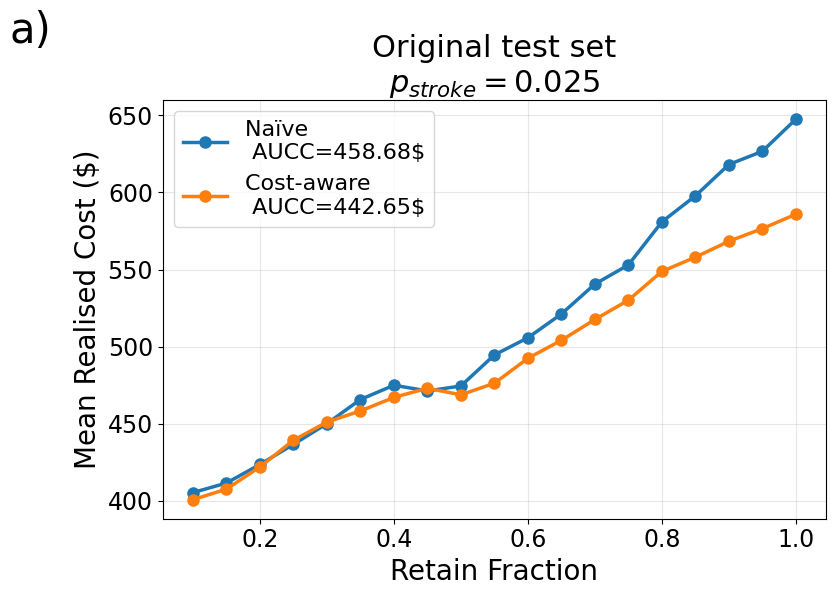

In [8]:
# ------------------------------------------------------------
# Plot cost-coverage curve only
# ------------------------------------------------------------

plt.rcParams.update({
    "font.size": 16,
    "axes.titlesize": 20,
    "axes.labelsize": 18,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "legend.fontsize": 15,
    "figure.titlesize": 24,
})

fig, ax = plt.subplots(figsize=(8, 6))

# Cost-coverage curve
ax.plot(
    retain_fractions,
    expected_costs_mag_filtered,
    marker="o",
    markersize=8,
    linewidth=2.5,
    label=f"Naïve \n AUCC={aucc_mag:.2f}$",
)

ax.plot(
    retain_fractions,
    expected_costs_ec_filtered,
    marker="o",
    markersize=8,
    linewidth=2.5,
    label=f"Cost-aware \n AUCC={aucc_ec:.2f}$",
)

ax.set_xlabel("Retain Fraction", fontsize=20)
ax.set_ylabel("Mean Realised Cost ($)", fontsize=20)
ax.set_title(
    "Original test set\n$p_{stroke}=0.025$",
    fontsize=22,
)

ax.tick_params(axis="both", labelsize=17)
ax.legend(fontsize=16)
ax.grid(True, alpha=0.3)
fig.text(
    -0.05, 1, "a)",
    #transform=axes[1].transAxes,
    fontsize=30,
    va="top",
    ha="left",
)

plt.tight_layout()

fig.savefig(
    "dtt_cost_coverage_original_test_set_25.pdf",
    format="pdf",
    bbox_inches="tight",
)

plt.show()

### augmented test set

/tmp/ipykernel_4173255/4091146114.py:94: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  aurc_mag = np.trapz(risks_mag_filtered, retain_fractions)
/tmp/ipykernel_4173255/4091146114.py:95: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  aurc_ec = np.trapz(risks_ec_filtered, retain_fractions)
/tmp/ipykernel_4173255/4091146114.py:97: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  aucc_mag = np.trapz(expected_costs_mag_filtered, retain_fractions)
/tmp/ipykernel_4173255/4091146114.py:98: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  aucc_ec = np.trapz(expected_costs_ec_filtered, retain_fractions)


AURC naive rule:      0.4197
AURC cost-aware rule: 0.4481

AUCC naive rule:      669.0770$
AUCC cost-aware rule: 672.2776$


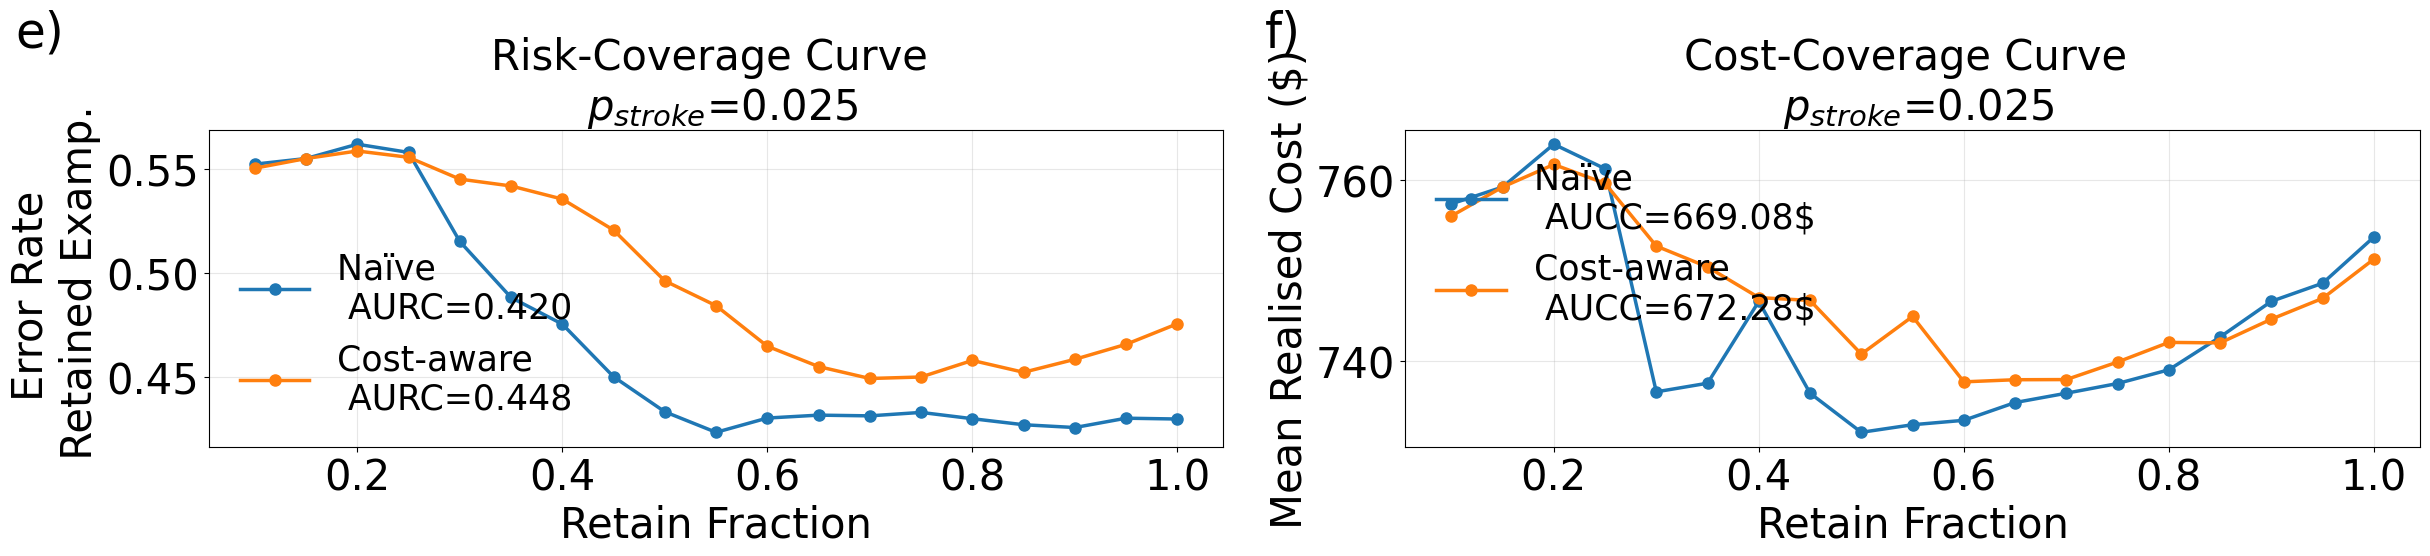

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Risk-coverage / cost-coverage analysis
# ------------------------------------------------------------

retain_fractions = np.linspace(0.1, 1.0, 19)

risks_mag_filtered = []
risks_ec_filtered = []

expected_costs_mag_filtered = []
expected_costs_ec_filtered = []
cost_fn = partial(compute_single_prediction_cost,p_stroke_missed_af=0.025)

for rf in retain_fractions:

    # --------------------------------------------------------
    # Naive rule: retain by probability magnitude / confidence
    # --------------------------------------------------------
    out_mag_filtered = evaluate_va_prob_magnitude_filtering(
        intervals=np.squeeze(intervals_noise),
        y_true=test_noise_gts,
        retain_fraction=rf,
        pred_method="collapse",
    )

    remaining_probs_mag = out_mag_filtered["arrays"]["retained_p_hat"]
    remaining_gts_mag = out_mag_filtered["arrays"]["retained_y_true"]

    remaining_preds_mag = (remaining_probs_mag >= 0.5).astype(int)

    risk_mag = np.mean(remaining_preds_mag != remaining_gts_mag)
    risks_mag_filtered.append(risk_mag)

    cost_mag = compute_af_screening_cost(
        preds_AF,
        gts_AF,
        remaining_probs_mag,
        remaining_gts_mag,
        p_stroke_missed_af=.025,
    )["expected_cost"]

    expected_costs_mag_filtered.append(cost_mag)

    # --------------------------------------------------------
    # Cost-aware rule: reject by expected decision cost
    # --------------------------------------------------------
    out_ec_filtered = evaluate_va_expected_cost_filtering(
        intervals=np.squeeze(intervals_noise),
        y_true=test_noise_gts,
        cost_fn=cost_fn,
        threshold=0.381,
        reject_fraction=1 - rf,
        pred_method="collapse",
    )

    remaining_probs_ec = out_ec_filtered["arrays"]["retained_p_hat"]
    remaining_gts_ec = out_ec_filtered["arrays"]["retained_y_true"]

    remaining_preds_ec = (remaining_probs_ec >= 0.381).astype(int)

    risk_ec = np.mean(remaining_preds_ec != remaining_gts_ec)
    risks_ec_filtered.append(risk_ec)

    cost_ec = compute_af_screening_cost(
        preds_AF,
        gts_AF,
        remaining_probs_ec,
        remaining_gts_ec,
        p_stroke_missed_af=.025,
        threshold = .381,
    )["expected_cost"]

    expected_costs_ec_filtered.append(cost_ec)


# ------------------------------------------------------------
# Convert to arrays
# ------------------------------------------------------------

risks_mag_filtered = np.asarray(risks_mag_filtered)
risks_ec_filtered = np.asarray(risks_ec_filtered)

expected_costs_mag_filtered = np.asarray(expected_costs_mag_filtered)
expected_costs_ec_filtered = np.asarray(expected_costs_ec_filtered)


# ------------------------------------------------------------
# Compute summary metrics
# ------------------------------------------------------------

aurc_mag = np.trapz(risks_mag_filtered, retain_fractions)
aurc_ec = np.trapz(risks_ec_filtered, retain_fractions)

aucc_mag = np.trapz(expected_costs_mag_filtered, retain_fractions)
aucc_ec = np.trapz(expected_costs_ec_filtered, retain_fractions)

print(f"AURC naive rule:      {aurc_mag:.4f}")
print(f"AURC cost-aware rule: {aurc_ec:.4f}")
print()
print(f"AUCC naive rule:      {aucc_mag:.4f}$")
print(f"AUCC cost-aware rule: {aucc_ec:.4f}$")


# ------------------------------------------------------------
# Plot risk-coverage and cost-coverage curves
# ------------------------------------------------------------

# ------------------------------------------------------------
# Plot risk-coverage and cost-coverage curves
# ------------------------------------------------------------

# Larger global font settings
plt.rcParams.update({
    "font.size": 30,
    "axes.titlesize": 30,
    "axes.labelsize": 30,
    "xtick.labelsize": 30,
    "ytick.labelsize": 30,
    "legend.fontsize": 30,
    "figure.titlesize": 30,
})

fig, axes = plt.subplots(1, 2, figsize=(25, 6))

# Risk-coverage curve
axes[0].plot(
    retain_fractions,
    risks_mag_filtered,
    marker="o",
    markersize=8,
    linewidth=2.5,
    label=f"Naïve \n AURC={aurc_mag:.3f}",
)

axes[0].plot(
    retain_fractions,
    risks_ec_filtered,
    marker="o",
    markersize=8,
    linewidth=2.5,
    label=f"Cost-aware \n AURC={aurc_ec:.3f}",
)

axes[0].set_xlabel("Retain Fraction")#, fontsize=20)
axes[0].set_ylabel("Error Rate \n Retained Examp.")#, fontsize=20)
axes[0].set_title("Risk-Coverage Curve \n $p_{stroke}$=0.025")#, fontsize=22)
axes[0].tick_params(axis="both")#, labelsize=17)
axes[0].legend(fontsize=35)
axes[0].grid(True, alpha=0.3)


# Cost-coverage curve
axes[1].plot(
    retain_fractions,
    expected_costs_mag_filtered,
    marker="o",
    markersize=8,
    linewidth=2.5,
    label=f"Naïve \n AUCC={aucc_mag:.2f}$",
)

axes[1].plot(
    retain_fractions,
    expected_costs_ec_filtered,
    marker="o",
    markersize=8,
    linewidth=2.5,
    label=f"Cost-aware \n AUCC={aucc_ec:.2f}$",
)

axes[1].set_xlabel("Retain Fraction")#, fontsize=20)
axes[1].set_ylabel("Mean Realised Cost ($)")#, fontsize=20)
axes[1].set_title("Cost-Coverage Curve \n $p_{stroke}$=0.025")#, fontsize=22)
axes[1].tick_params(axis="both")#, labelsize=17)
axes[1].legend(fontsize=30)
axes[1].grid(True, alpha=0.3)

# Main title
#fig.suptitle("Augmented Test Set", fontsize=35, y=.9, x=.43)

fig.text(
    0.02, 0.97, "e)",
    #transform=axes[0].transAxes,
    fontsize=35,
    va="top",
    ha="left",
)

fig.text(
    0.52, 0.97, "f)",
    #transform=axes[1].transAxes,
    fontsize=35,
    va="top",
    ha="left",
)

axes[0].legend(
    fontsize=25,
    loc="lower left",
    #bbox_to_anchor=(1.02, 0.5),
    frameon=False,
)

axes[1].legend(
    fontsize=25,
    loc="upper left",
    #bbox_to_anchor=(1.02, 0.5),
    frameon=False,
)
# Leave room for suptitle
# Leave room for suptitle
plt.tight_layout()

plt.show()

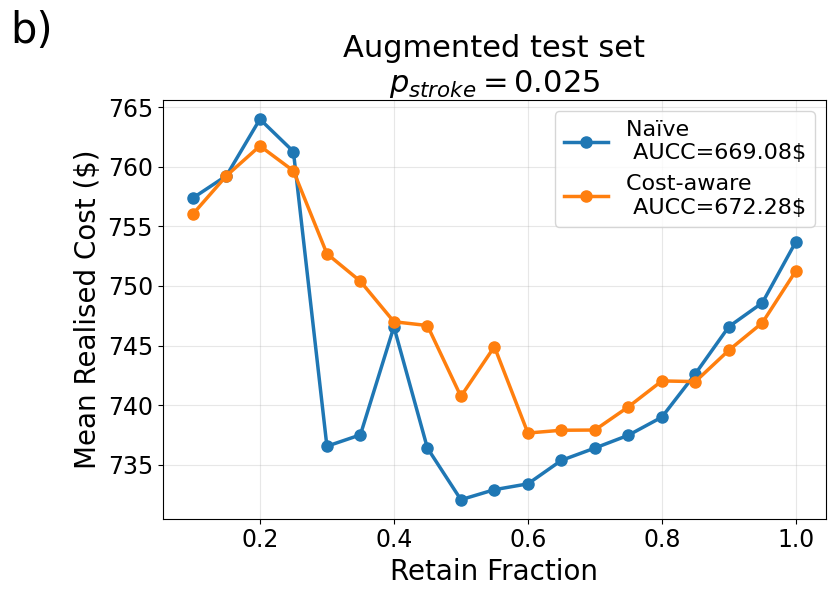

In [10]:
# ------------------------------------------------------------
# Plot cost-coverage curve only
# ------------------------------------------------------------

plt.rcParams.update({
    "font.size": 16,
    "axes.titlesize": 20,
    "axes.labelsize": 18,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "legend.fontsize": 15,
    "figure.titlesize": 24,
})

fig, ax = plt.subplots(figsize=(8, 6))

# Cost-coverage curve
ax.plot(
    retain_fractions,
    expected_costs_mag_filtered,
    marker="o",
    markersize=8,
    linewidth=2.5,
    label=f"Naïve \n AUCC={aucc_mag:.2f}$",
)

ax.plot(
    retain_fractions,
    expected_costs_ec_filtered,
    marker="o",
    markersize=8,
    linewidth=2.5,
    label=f"Cost-aware \n AUCC={aucc_ec:.2f}$",
)

ax.set_xlabel("Retain Fraction", fontsize=20)
ax.set_ylabel("Mean Realised Cost ($)", fontsize=20)
ax.set_title(
    "Augmented test set\n$p_{stroke}=0.025$",
    fontsize=22,
)

ax.tick_params(axis="both", labelsize=17)
ax.legend(fontsize=16)
ax.grid(True, alpha=0.3)
fig.text(
    -0.05, 1, "b)",
    #transform=axes[1].transAxes,
    fontsize=30,
    va="top",
    ha="left",
)

plt.tight_layout()

fig.savefig(
    "dtt_cost_coverage_augmented_test_set_25.pdf",
    format="pdf",
    bbox_inches="tight",
)

plt.show()

# error composition

In [11]:
out_mag_filtered = evaluate_va_prob_magnitude_filtering(
    intervals=np.squeeze(intervals_noise),
    y_true=test_noise_gts,
    retain_fraction=0.5,
    pred_method="collapse",
)

def print_confusion_percentages(out, subset,tag):
    tp = out[subset]["tp"]
    fp = out[subset]["fp"]
    tn = out[subset]["tn"]
    fn = out[subset]["fn"]

    total = tp + fp + tn + fn

    print(f"\n{subset.upper()}")
    print(f"\n{tag.upper()}")
    print("-" * 30)
    print(f"Total: {total}")

    if total == 0:
        print("No examples in this subset.")
        return
    
    print(f"TP: {tp} ({100 * tp / total:.2f}%)")
    print(f"FP: {fp} ({100 * fp / total:.2f}%)")
    print(f"TN: {tn} ({100 * tn / total:.2f}%)")
    print(f"FN: {fn} ({100 * fn / total:.2f}%)")


print_confusion_percentages(out_mag_filtered, "overall",'Prob filter noisy')
print_confusion_percentages(out_mag_filtered, "rejected",'Prob filter noisy')
print_confusion_percentages(out_mag_filtered, "retained",'Prob retained noisy')


OVERALL

PROB FILTER NOISY
------------------------------
Total: 15377
TP: 2930 (19.05%)
FP: 3746 (24.36%)
TN: 5834 (37.94%)
FN: 2867 (18.64%)

REJECTED

PROB FILTER NOISY
------------------------------
Total: 7689
TP: 1114 (14.49%)
FP: 1420 (18.47%)
TN: 3295 (42.85%)
FN: 1860 (24.19%)

RETAINED

PROB RETAINED NOISY
------------------------------
Total: 7688
TP: 1816 (23.62%)
FP: 2326 (30.25%)
TN: 2539 (33.03%)
FN: 1007 (13.10%)


In [12]:
cost_fn = partial(compute_single_prediction_cost,p_stroke_missed_af=0.025)

out_ec_filtered = evaluate_va_expected_cost_filtering(
    intervals=np.squeeze(intervals_noise),
    y_true=test_noise_gts,
    cost_fn=cost_fn,
    threshold=0.381,
    reject_fraction=0.5,
    pred_method="collapse",
)



print_confusion_percentages(out_ec_filtered, "overall",'ec filtered noisy')
print_confusion_percentages(out_ec_filtered, "rejected",'ec filtered noisy')
print_confusion_percentages(out_ec_filtered, "retained",'ec retained noisy')


OVERALL

EC FILTERED NOISY
------------------------------
Total: 15377
TP: 4137 (26.90%)
FP: 5656 (36.78%)
TN: 3924 (25.52%)
FN: 1660 (10.80%)

REJECTED

EC FILTERED NOISY
------------------------------
Total: 7689
TP: 1446 (18.81%)
FP: 2231 (29.02%)
TN: 2743 (35.67%)
FN: 1269 (16.50%)

RETAINED

EC RETAINED NOISY
------------------------------
Total: 7688
TP: 2691 (35.00%)
FP: 3425 (44.55%)
TN: 1181 (15.36%)
FN: 391 (5.09%)


In [13]:
cost_fn = partial(compute_single_prediction_cost,p_stroke_missed_af=0.025)

out_ec_filtered = evaluate_va_expected_cost_filtering(
    intervals=np.squeeze(intervals),
    y_true=test_gts,
    cost_fn=cost_fn,
    threshold=0.381,
    reject_fraction=.5,
    pred_method="collapse",
)




print_confusion_percentages(out_ec_filtered, "overall",'ec filtered clean')
print_confusion_percentages(out_ec_filtered, "rejected",'ec filtered clean')


OVERALL

EC FILTERED CLEAN
------------------------------
Total: 15377
TP: 4349 (28.28%)
FP: 2316 (15.06%)
TN: 7264 (47.24%)
FN: 1448 (9.42%)

REJECTED

EC FILTERED CLEAN
------------------------------
Total: 7689
TP: 2325 (30.24%)
FP: 2054 (26.71%)
TN: 2335 (30.37%)
FN: 975 (12.68%)


In [14]:
out_mag_filtered = evaluate_va_prob_magnitude_filtering(
    intervals=np.squeeze(intervals),
    y_true=test_gts,
    retain_fraction=0.5,
    pred_method="collapse",
)




print_confusion_percentages(out_mag_filtered, "overall",'prob filtered clean')
print_confusion_percentages(out_mag_filtered, "rejected",'prob filtered clean')


OVERALL

PROB FILTERED CLEAN
------------------------------
Total: 15377
TP: 2333 (15.17%)
FP: 409 (2.66%)
TN: 9171 (59.64%)
FN: 3464 (22.53%)

REJECTED

PROB FILTERED CLEAN
------------------------------
Total: 7689
TP: 1097 (14.27%)
FP: 368 (4.79%)
TN: 3408 (44.32%)
FN: 2816 (36.62%)


In [15]:
# ============================================================================
# CONSOLIDATED SOFTWARE VERIFICATION TEST CELL
# Tests TC-01 to TC-14 from the Verification and Validation Report
# Run this cell only after all data-loading, interval-generation, helper-function,
# clean-analysis, and augmented-analysis cells have completed successfully.
# ============================================================================

import numpy as np
from functools import partial

# Controlled configuration for VB_25_dtt
P_STROKE = 0.025
COST_AWARE_THRESHOLD = 0.381
EXPECTED_TEST_COUNT = 15377
AUDIT_RETAIN_FRACTION = 0.5
RETAIN_FRACTIONS = np.linspace(0.1, 1.0, 19)
ATOL_INTERVAL = 1e-10
ATOL_COST = 1e-9
ATOL_REPORTED = 5e-5  # reported reference values are rounded to 4 decimal places

TEST_STATUS = {}


def heading(test_id, title):
    print("\n" + "=" * 88)
    print(f"{test_id}: {title}")
    print("=" * 88)


def passed(test_id, message):
    TEST_STATUS[test_id] = "PASS"
    print(f"{test_id} PASS: {message}")


def require_objects(names):
    missing = [name for name in names if name not in globals()]
    if missing:
        raise NameError("Missing required notebook object(s):\n - " + "\n - ".join(missing))


def as_1d(values, dtype=None):
    return np.asarray(values, dtype=dtype).reshape(-1)


def as_intervals(values):
    arr = np.asarray(values, dtype=float)
    arr = np.squeeze(arr)
    if arr.ndim != 2 or arr.shape[1] != 2:
        raise AssertionError(f"Expected interval array with shape (n, 2), got {arr.shape}.")
    return arr


def collapsed_probability(interval_array):
    arr = as_intervals(interval_array)
    p0 = np.minimum(arr[:, 0], arr[:, 1])
    p1 = np.maximum(arr[:, 0], arr[:, 1])
    return p1 / np.maximum(1.0 - p0 + p1, 1e-15)


def confusion_counts(y_true, y_pred):
    yt = as_1d(y_true, int)
    yp = as_1d(y_pred, int)
    return {
        "TP": int(np.sum((yt == 1) & (yp == 1))),
        "FP": int(np.sum((yt == 0) & (yp == 1))),
        "TN": int(np.sum((yt == 0) & (yp == 0))),
        "FN": int(np.sum((yt == 1) & (yp == 0))),
    }


def assert_confusion(actual, expected, label):
    if actual != expected:
        raise AssertionError(f"{label} mismatch. Expected {expected}, got {actual}.")
    if sum(actual.values()) <= 0:
        raise AssertionError(f"{label} has an invalid zero total.")


def compute_curve_outputs(interval_array, labels):
    """Reproduce the notebook retain-only risk/cost curves for one dataset."""
    risks_mag, risks_ec = [], []
    costs_mag, costs_ec = [], []
    cost_fn = partial(compute_single_prediction_cost, p_stroke_missed_af=P_STROKE)

    for retain_fraction in RETAIN_FRACTIONS:
        naive = evaluate_va_prob_magnitude_filtering(
            intervals=as_intervals(interval_array),
            y_true=labels,
            retain_fraction=float(retain_fraction),
            pred_method="collapse",
        )
        p_naive = naive["arrays"]["retained_p_hat"]
        y_naive = naive["arrays"]["retained_y_true"]
        pred_naive = (p_naive >= 0.5).astype(int)
        risks_mag.append(float(np.mean(pred_naive != y_naive)))
        costs_mag.append(compute_af_screening_cost(
            preds_AF,
            gts_AF,
            p_naive,
            y_naive,
            p_stroke_missed_af=P_STROKE,
        )["expected_cost"])

        cost_aware = evaluate_va_expected_cost_filtering(
            intervals=as_intervals(interval_array),
            y_true=labels,
            cost_fn=cost_fn,
            threshold=COST_AWARE_THRESHOLD,
            reject_fraction=float(1.0 - retain_fraction),
            pred_method="collapse",
        )
        p_ec = cost_aware["arrays"]["retained_p_hat"]
        y_ec = cost_aware["arrays"]["retained_y_true"]
        pred_ec = (p_ec >= COST_AWARE_THRESHOLD).astype(int)
        risks_ec.append(float(np.mean(pred_ec != y_ec)))
        costs_ec.append(compute_af_screening_cost(
            preds_AF,
            gts_AF,
            p_ec,
            y_ec,
            threshold=COST_AWARE_THRESHOLD,
            p_stroke_missed_af=P_STROKE,
        )["expected_cost"])

    risks_mag = np.asarray(risks_mag, dtype=float)
    risks_ec = np.asarray(risks_ec, dtype=float)
    costs_mag = np.asarray(costs_mag, dtype=float)
    costs_ec = np.asarray(costs_ec, dtype=float)

    return {
        "risks_mag": risks_mag,
        "risks_ec": risks_ec,
        "costs_mag": costs_mag,
        "costs_ec": costs_ec,
        "aurc_mag": float(np.trapz(risks_mag, RETAIN_FRACTIONS)),
        "aurc_ec": float(np.trapz(risks_ec, RETAIN_FRACTIONS)),
        "aucc_mag": float(np.trapz(costs_mag, RETAIN_FRACTIONS)),
        "aucc_ec": float(np.trapz(costs_ec, RETAIN_FRACTIONS)),
    }


# ----------------------------------------------------------------------------
# Objects required by the complete TC-01 to TC-14 audit
# ----------------------------------------------------------------------------
required = [
    "predict_interval",
    "compute_single_prediction_cost",
    "compute_af_screening_cost",
    "evaluate_va_prob_magnitude_filtering",
    "evaluate_va_expected_cost_filtering",
    "preds",
    "gts",
    "preds_AF",
    "gts_AF",
    "test_preds",
    "test_gts",
    "test_preds_AF",
    "intervals",
    "test_noise_preds",
    "test_noise_gts",
    "test_noise_preds_AF",
    "intervals_noise",
]
require_objects(required)

clean_intervals = as_intervals(intervals)
noise_intervals = as_intervals(intervals_noise)
clean_labels = as_1d(test_gts, int)
noise_labels = as_1d(test_noise_gts, int)
clean_p_hat = collapsed_probability(clean_intervals)
noise_p_hat = collapsed_probability(noise_intervals)
cost_fn_025 = partial(compute_single_prediction_cost, p_stroke_missed_af=P_STROKE)


# TC-01 ----------------------------------------------------------------------
heading("TC-01", "Required objects, counts and alignment")
assert len(preds_AF) == len(gts_AF) == 15081
assert len(test_preds_AF) == len(clean_labels) == len(clean_intervals) == EXPECTED_TEST_COUNT
assert len(test_noise_preds_AF) == len(noise_labels) == len(noise_intervals) == EXPECTED_TEST_COUNT
assert np.array_equal(clean_labels, noise_labels), "Noise augmentation should retain the test labels."
print(f"Calibration examples: {len(preds_AF):,}")
print(f"Clean test examples: {len(clean_labels):,}")
print(f"Augmented test examples: {len(noise_labels):,}")
passed("TC-01", "required objects exist and prediction, label and interval arrays are aligned.")


# TC-02 ----------------------------------------------------------------------
heading("TC-02", "Two-class probability integrity and AF-column extraction")
for name, matrix in (("calibration", preds), ("clean test", test_preds), ("augmented test", test_noise_preds)):
    matrix = np.asarray(matrix, dtype=float)
    assert matrix.ndim == 2 and matrix.shape[1] == 2, f"{name} matrix must have two columns."
    assert np.all(np.isfinite(matrix)), f"{name} matrix contains non-finite values."
    assert np.all((matrix >= 0.0) & (matrix <= 1.0)), f"{name} probabilities are outside [0, 1]."
    np.testing.assert_allclose(matrix.sum(axis=1), 1.0, atol=1e-6, rtol=0.0)
np.testing.assert_array_equal(np.asarray(preds_AF), np.asarray(preds)[:, 1])
np.testing.assert_array_equal(np.asarray(test_preds_AF), np.asarray(test_preds)[:, 1])
np.testing.assert_array_equal(np.asarray(test_noise_preds_AF), np.asarray(test_noise_preds)[:, 1])
passed("TC-02", "probability matrices are valid and AF probabilities are taken from column 1.")


# TC-03 ----------------------------------------------------------------------
heading("TC-03", "Prediction-cardinality diagnostics")
def report_cardinality(name, values):
    values = as_1d(values, float)
    exact = np.unique(values).size
    assert exact >= 2, f"{name} is degenerate."
    print(f"{name}: total={len(values):,}, exact unique={exact:,} ({exact/len(values):.3%})")
    for decimals in (12, 8, 6, 4, 3):
        count = np.unique(np.round(values, decimals)).size
        print(f"  unique at {decimals:2d} dp: {count:,}")
report_cardinality("Calibration predictions", preds_AF)
report_cardinality("Clean test predictions", test_preds_AF)
report_cardinality("Collapsed Venn-Abers probabilities", clean_p_hat)
passed("TC-03", "prediction arrays are non-degenerate and cardinality diagnostics were recorded.")


# TC-04 ----------------------------------------------------------------------
heading("TC-04", "Venn-Abers deterministic reproducibility")
n_repeat = min(25, len(test_preds_AF))
first = np.asarray([
    np.squeeze(predict_interval(p, preds_AF, gts_AF))
    for p in np.asarray(test_preds_AF)[:n_repeat]
])
second = np.asarray([
    np.squeeze(predict_interval(p, preds_AF, gts_AF))
    for p in np.asarray(test_preds_AF)[:n_repeat]
])
np.testing.assert_allclose(first, second, atol=0.0, rtol=0.0)
passed("TC-04", f"identical inputs produced identical intervals for {n_repeat} checked examples.")


# TC-05 ----------------------------------------------------------------------
heading("TC-05", "Stored Venn-Abers interval provenance")
indices = np.linspace(0, EXPECTED_TEST_COUNT - 1, 25, dtype=int)
stored = np.sort(np.asarray(intervals)[indices].reshape(25, 2), axis=1)
recomputed = np.sort(np.asarray([
    np.squeeze(predict_interval(test_preds_AF[i], preds_AF, gts_AF))
    for i in indices
]).reshape(25, 2), axis=1)
differences = np.abs(stored.astype(float) - recomputed.astype(float))
np.testing.assert_allclose(stored, recomputed, atol=ATOL_INTERVAL, rtol=0.0)
print(f"Checked examples: {len(indices)}")
print(f"Maximum endpoint difference: {differences.max():.12g}")
print(f"Mean endpoint difference: {differences.mean():.12g}")
passed("TC-05", "stored intervals were reproduced from the controlled source arrays and implementation.")


# TC-06 ----------------------------------------------------------------------
heading("TC-06", "Decision-theoretic threshold")
C_FP = 614.0 + 76.15
C_FN = P_STROKE * 44929.0
exact_threshold = C_FP / (C_FP + C_FN)
np.testing.assert_allclose(exact_threshold, 0.3805886813262563, atol=1e-15, rtol=0.0)
assert round(exact_threshold, 3) == COST_AWARE_THRESHOLD
at_crossing = compute_single_prediction_cost(
    exact_threshold,
    threshold=exact_threshold,
    p_stroke_missed_af=P_STROKE,
    tp_mode="net",
    include_screen_cost_for_all=True,
)
np.testing.assert_allclose(
    at_crossing["expected_cost_if_positive"],
    at_crossing["expected_cost_if_negative"],
    atol=ATOL_COST,
    rtol=0.0,
)
print(f"Exact threshold: {exact_threshold:.12f}")
print(f"Implemented threshold: {COST_AWARE_THRESHOLD:.3f}")
passed("TC-06", "the configured threshold agrees with the analytical net-cost crossover.")


# Create controlled 50% results used by TC-07 to TC-10 and TC-14
clean_naive_50 = evaluate_va_prob_magnitude_filtering(
    clean_intervals,
    clean_labels,
    retain_fraction=AUDIT_RETAIN_FRACTION,
    pred_method="collapse",
)
clean_cost_50 = evaluate_va_expected_cost_filtering(
    clean_intervals,
    clean_labels,
    cost_fn=cost_fn_025,
    threshold=COST_AWARE_THRESHOLD,
    reject_fraction=1.0 - AUDIT_RETAIN_FRACTION,
    pred_method="collapse",
)
noise_naive_50 = evaluate_va_prob_magnitude_filtering(
    noise_intervals,
    noise_labels,
    retain_fraction=AUDIT_RETAIN_FRACTION,
    pred_method="collapse",
)
noise_cost_50 = evaluate_va_expected_cost_filtering(
    noise_intervals,
    noise_labels,
    cost_fn=cost_fn_025,
    threshold=COST_AWARE_THRESHOLD,
    reject_fraction=1.0 - AUDIT_RETAIN_FRACTION,
    pred_method="collapse",
)


# TC-07 ----------------------------------------------------------------------
heading("TC-07", "50% filtering counts and mask partition")
expected_rejected = int(np.ceil(0.5 * EXPECTED_TEST_COUNT))
expected_retained = EXPECTED_TEST_COUNT - expected_rejected
for label, output in (("naive", clean_naive_50), ("cost-aware", clean_cost_50)):
    retain_mask = output["arrays"]["retain_mask"]
    reject_mask = output["arrays"]["reject_mask"]
    assert not np.any(retain_mask & reject_mask)
    assert np.all(retain_mask | reject_mask)
    assert int(retain_mask.sum()) == expected_retained
    assert int(reject_mask.sum()) == expected_rejected
    print(f"{label}: retained={retain_mask.sum():,}, rejected={reject_mask.sum():,}")
passed("TC-07", "both filters produced complete, exclusive 7,688/7,689 partitions.")


# TC-08 ----------------------------------------------------------------------
heading("TC-08", "Naive rejection ranking")
naive_mag = clean_naive_50["arrays"]["prob_magnitude"]
naive_retain = clean_naive_50["arrays"]["retain_mask"]
naive_reject = clean_naive_50["arrays"]["reject_mask"]
assert np.max(naive_mag[naive_reject]) <= np.min(naive_mag[naive_retain]) + 1e-15
naive_distance = np.abs(clean_naive_50["arrays"]["p_hat"] - 0.5)
assert np.max(naive_distance[naive_reject]) <= np.min(naive_distance[naive_retain]) + 1e-15
passed("TC-08", "the naive rule rejected collapsed probabilities closest to 0.5, allowing boundary ties.")


# TC-09 ----------------------------------------------------------------------
heading("TC-09", "Cost-aware score calculation and ranking")
p = clean_cost_50["arrays"]["p_hat"]
y_pred = (p >= COST_AWARE_THRESHOLD).astype(int)
C_screen = 300.0 + 76.15
expected_positive = (1.0 - p) * C_FP + C_screen  # C_TP=0 in net mode
expected_negative = p * C_FN + C_screen          # C_TN=0
expected_selected = np.where(y_pred == 1, expected_positive, expected_negative)
np.testing.assert_allclose(
    clean_cost_50["arrays"]["expected_cost_if_positive"],
    expected_positive,
    atol=ATOL_COST,
    rtol=0.0,
)
np.testing.assert_allclose(
    clean_cost_50["arrays"]["expected_cost_if_negative"],
    expected_negative,
    atol=ATOL_COST,
    rtol=0.0,
)
np.testing.assert_allclose(
    clean_cost_50["arrays"]["expected_action_cost"],
    expected_selected,
    atol=ATOL_COST,
    rtol=0.0,
)
np.testing.assert_array_equal(clean_cost_50["arrays"]["y_pred"], y_pred)
ec_retain = clean_cost_50["arrays"]["retain_mask"]
ec_reject = clean_cost_50["arrays"]["reject_mask"]
assert np.max(expected_selected[ec_retain]) <= np.min(expected_selected[ec_reject]) + ATOL_COST
passed("TC-09", "expected-cost arrays and highest-selected-cost-first rejection ordering are correct.")


# TC-10 ----------------------------------------------------------------------
heading("TC-10", "Ground-truth leakage")
rng = np.random.default_rng(20260730)
permuted_labels = rng.permutation(clean_labels)
permuted_naive = evaluate_va_prob_magnitude_filtering(
    clean_intervals,
    permuted_labels,
    retain_fraction=0.5,
    pred_method="collapse",
)
permuted_cost = evaluate_va_expected_cost_filtering(
    clean_intervals,
    permuted_labels,
    cost_fn=cost_fn_025,
    threshold=COST_AWARE_THRESHOLD,
    reject_fraction=0.5,
    pred_method="collapse",
)
np.testing.assert_array_equal(
    clean_naive_50["arrays"]["reject_mask"],
    permuted_naive["arrays"]["reject_mask"],
)
np.testing.assert_array_equal(
    clean_cost_50["arrays"]["reject_mask"],
    permuted_cost["arrays"]["reject_mask"],
)
passed("TC-10", "naive and cost-aware rejection masks are independent of test ground truth.")


# TC-11 ----------------------------------------------------------------------
heading("TC-11", "Coverage-curve construction")
assert len(RETAIN_FRACTIONS) == 19
np.testing.assert_allclose(RETAIN_FRACTIONS, np.linspace(0.1, 1.0, 19), atol=0.0, rtol=0.0)
assert np.all(np.diff(RETAIN_FRACTIONS) > 0)
clean_curves = compute_curve_outputs(clean_intervals, clean_labels)
noise_curves = compute_curve_outputs(noise_intervals, noise_labels)
for dataset_name, curves in (("clean", clean_curves), ("augmented", noise_curves)):
    for key in ("risks_mag", "risks_ec", "costs_mag", "costs_ec"):
        values = curves[key]
        assert len(values) == 19, f"{dataset_name} {key} does not have 19 values."
        assert np.all(np.isfinite(values)), f"{dataset_name} {key} contains non-finite values."
passed("TC-11", "clean and augmented curve arrays contain 19 aligned, finite values.")


# TC-12 ----------------------------------------------------------------------
heading("TC-12", "Original test-set summary outputs")
clean_reference = {
    "aurc_mag": 0.1042,
    "aurc_ec": 0.1064,
    "aucc_mag": 447.7850,
    "aucc_ec": 435.6134,
}
for key, expected in clean_reference.items():
    actual = clean_curves[key]
    np.testing.assert_allclose(actual, expected, atol=ATOL_REPORTED, rtol=0.0)
    print(f"{key}: {actual:.4f} (reference {expected:.4f})")
passed("TC-12", "original-test AURC and AUCC values match the controlled reference outputs.")


# TC-13 ----------------------------------------------------------------------
heading("TC-13", "Augmented test-set summary outputs")
noise_reference = {
    "aurc_mag": 0.4509,
    "aurc_ec": 0.4740,
    "aucc_mag": 682.0591,
    "aucc_ec": 686.2742,
}
for key, expected in noise_reference.items():
    actual = noise_curves[key]
    np.testing.assert_allclose(actual, expected, atol=ATOL_REPORTED, rtol=0.0)
    print(f"{key}: {actual:.4f} (reference {expected:.4f})")
passed("TC-13", "augmented-test AURC and AUCC values match the controlled reference outputs.")


# TC-14 ----------------------------------------------------------------------
heading("TC-14", "50% confusion-composition outputs")
expected_confusions = {
    "noise_naive_overall": {"TP": 3149, "FP": 4193, "TN": 5387, "FN": 2648},
    "noise_naive_rejected": {"TP": 846, "FP": 1147, "TN": 3759, "FN": 1937},
    "noise_naive_retained": {"TP": 2303, "FP": 3046, "TN": 1628, "FN": 711},
    "noise_cost_overall": {"TP": 4207, "FP": 6136, "TN": 3444, "FN": 1590},
    "noise_cost_rejected": {"TP": 1228, "FP": 2187, "TN": 2938, "FN": 1336},
    "noise_cost_retained": {"TP": 2979, "FP": 3949, "TN": 506, "FN": 254},
    "clean_cost_overall": {"TP": 4416, "FP": 2184, "TN": 7396, "FN": 1381},
    "clean_cost_rejected": {"TP": 2243, "FP": 1838, "TN": 2697, "FN": 911},
    "clean_cost_retained": {"TP": 2173, "FP": 346, "TN": 4699, "FN": 470},
    "clean_naive_overall": {"TP": 2404, "FP": 469, "TN": 9111, "FN": 3393},
    "clean_naive_rejected": {"TP": 910, "FP": 380, "TN": 3555, "FN": 2844},
    "clean_naive_retained": {"TP": 1494, "FP": 89, "TN": 5556, "FN": 549},
}

outputs = {
    "noise_naive": noise_naive_50,
    "noise_cost": noise_cost_50,
    "clean_cost": clean_cost_50,
    "clean_naive": clean_naive_50,
}

for prefix, output in outputs.items():
    yt = output["arrays"]["y_true"]
    yp = output["arrays"]["y_pred"]
    retain = output["arrays"]["retain_mask"]
    reject = output["arrays"]["reject_mask"]
    actual_overall = confusion_counts(yt, yp)
    actual_rejected = confusion_counts(yt[reject], yp[reject])
    actual_retained = confusion_counts(yt[retain], yp[retain])
    assert_confusion(actual_overall, expected_confusions[f"{prefix}_overall"], f"{prefix} overall")
    assert_confusion(actual_rejected, expected_confusions[f"{prefix}_rejected"], f"{prefix} rejected")
    assert_confusion(actual_retained, expected_confusions[f"{prefix}_retained"], f"{prefix} retained")
    for component in ("TP", "FP", "TN", "FN"):
        assert actual_overall[component] == actual_rejected[component] + actual_retained[component]
    assert sum(actual_overall.values()) == EXPECTED_TEST_COUNT
    assert sum(actual_rejected.values()) == expected_rejected
    assert sum(actual_retained.values()) == expected_retained
    print(f"{prefix}: overall={actual_overall}, rejected={actual_rejected}, retained={actual_retained}")
passed("TC-14", "all controlled confusion compositions and component-wise reconciliations are correct.")


# Overall summary -------------------------------------------------------------
print("\n" + "=" * 88)
print("VERIFICATION SUMMARY")
print("=" * 88)
for number in range(1, 15):
    test_id = f"TC-{number:02d}"
    print(f"{test_id}: {TEST_STATUS.get(test_id, 'NOT RUN')}")

if all(TEST_STATUS.get(f"TC-{number:02d}") == "PASS" for number in range(1, 15)):
    print("\nOVERALL VERIFICATION STATUS: PASS")
    print("All TC-01 to TC-14 checks passed for the executed VB_25_dtt configuration.")
else:
    raise AssertionError("One or more verification tests did not complete successfully.")



TC-01: Required objects, counts and alignment
Calibration examples: 15,081
Clean test examples: 15,377
Augmented test examples: 15,377
TC-01 PASS: required objects exist and prediction, label and interval arrays are aligned.

TC-02: Two-class probability integrity and AF-column extraction
TC-02 PASS: probability matrices are valid and AF probabilities are taken from column 1.

TC-03: Prediction-cardinality diagnostics
Calibration predictions: total=15,081, exact unique=15,076 (99.967%)
  unique at 12 dp: 14,991
  unique at  8 dp: 14,322
  unique at  6 dp: 13,508
  unique at  4 dp: 6,862
  unique at  3 dp: 992
Clean test predictions: total=15,377, exact unique=15,371 (99.961%)
  unique at 12 dp: 15,052
  unique at  8 dp: 14,035
  unique at  6 dp: 12,972
  unique at  4 dp: 6,426
  unique at  3 dp: 993
Collapsed Venn-Abers probabilities: total=15,377, exact unique=427 (2.777%)
  unique at 12 dp: 427
  unique at  8 dp: 426
  unique at  6 dp: 421
  unique at  4 dp: 331
  unique at  3 dp: 2

/tmp/ipykernel_4173255/1910098484.py:134: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  "aurc_mag": float(np.trapz(risks_mag, RETAIN_FRACTIONS)),
/tmp/ipykernel_4173255/1910098484.py:135: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  "aurc_ec": float(np.trapz(risks_ec, RETAIN_FRACTIONS)),
/tmp/ipykernel_4173255/1910098484.py:136: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  "aucc_mag": float(np.trapz(costs_mag, RETAIN_FRACTIONS)),
/tmp/ipykernel_4173255/1910098484.py:137: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  "aucc_ec": float(np.trapz(costs_ec, RETAIN_FRACTIONS)),
/tmp/ipykernel_4173255/1910098484.py:134: Deprecatio

TC-11 PASS: clean and augmented curve arrays contain 19 aligned, finite values.

TC-12: Original test-set summary outputs


AssertionError: 
Not equal to tolerance rtol=0, atol=5e-05

Mismatched elements: 1 / 1 (100%)
Max absolute difference among violations: 0.00727004
Max relative difference among violations: 0.06977003
 ACTUAL: array(0.11147)
 DESIRED: array(0.1042)

In [16]:
# TC-15 ----------------------------------------------------------------------
heading("TC-15", "Retain-only versus negative-reject pathway functionality")

def realised_mean_cost_from_predictions(
    probabilities,
    labels,
    threshold,
):
    """
    Calculate mean realised cost directly from per-example predictions.

    This provides an independent check of the aggregate
    compute_af_screening_cost calculation.
    """
    probabilities = as_1d(probabilities, float)
    labels = as_1d(labels, int)

    assert len(probabilities) == len(labels)
    assert np.all(np.isfinite(probabilities))
    assert np.all((probabilities >= 0.0) & (probabilities <= 1.0))
    assert np.all(np.isin(labels, [0, 1]))

    realised_costs = np.asarray([
        compute_single_prediction_cost(
            pred=float(probability),
            true_label=int(true_label),
            threshold=threshold,
            predictions_are_probabilities=True,
            tp_mode="net",
            p_stroke_missed_af=P_STROKE,
            include_screen_cost_for_all=True,
            return_details=False,
        )
        for probability, true_label in zip(probabilities, labels)
    ])

    return float(np.mean(realised_costs))


def audit_retain_only_and_negative_reject(
    output,
    dataset_labels,
    threshold,
    filter_name,
):
    """
    Verify the two reject pathways.

    Retain-only:
        Calculate cost using retained examples only.

    Negative-reject:
        Reconstruct the full cohort, preserve retained probabilities,
        and assign probability zero to every rejected example.
    """
    dataset_labels = as_1d(dataset_labels, int)

    retain_mask = np.asarray(
        output["arrays"]["retain_mask"],
        dtype=bool,
    )
    reject_mask = np.asarray(
        output["arrays"]["reject_mask"],
        dtype=bool,
    )
    full_probabilities = as_1d(
        output["arrays"]["p_hat"],
        float,
    )
    output_labels = as_1d(
        output["arrays"]["y_true"],
        int,
    )

    # Basic partition checks
    assert len(full_probabilities) == EXPECTED_TEST_COUNT
    assert len(output_labels) == EXPECTED_TEST_COUNT
    assert len(retain_mask) == EXPECTED_TEST_COUNT
    assert len(reject_mask) == EXPECTED_TEST_COUNT

    np.testing.assert_array_equal(
        output_labels,
        dataset_labels,
    )

    assert not np.any(retain_mask & reject_mask)
    assert np.all(retain_mask | reject_mask)

    assert int(retain_mask.sum()) == expected_retained
    assert int(reject_mask.sum()) == expected_rejected

    # ------------------------------------------------------------------
    # 1. Retain-only pathway
    # ------------------------------------------------------------------
    retained_probabilities = full_probabilities[retain_mask]
    retained_labels = output_labels[retain_mask]

    retain_only_result = compute_af_screening_cost(
        preds_AF,
        gts_AF,
        retained_probabilities,
        retained_labels,
        threshold=threshold,
        predictions_are_probabilities=True,
        se_sp_source="test",
        prevalence_source="test",
        tp_mode="net",
        p_stroke_missed_af=P_STROKE,
    )

    retain_only_cost = retain_only_result["expected_cost"]

    # Independent realised-cost calculation
    retain_only_direct_cost = realised_mean_cost_from_predictions(
        retained_probabilities,
        retained_labels,
        threshold=threshold,
    )

    np.testing.assert_allclose(
        retain_only_cost,
        retain_only_direct_cost,
        atol=ATOL_COST,
        rtol=0.0,
    )

    assert (
        retain_only_result["test_stats"]["TP"]
        + retain_only_result["test_stats"]["FP"]
        + retain_only_result["test_stats"]["TN"]
        + retain_only_result["test_stats"]["FN"]
        == expected_retained
    )

    # ------------------------------------------------------------------
    # 2. Negative-reject pathway
    # ------------------------------------------------------------------
    negative_reject_probabilities = full_probabilities.copy()

    # Rejected cases must enter the negative pathway.
    negative_reject_probabilities[reject_mask] = 0.0

    # Retained probabilities must not be altered.
    np.testing.assert_allclose(
        negative_reject_probabilities[retain_mask],
        full_probabilities[retain_mask],
        atol=0.0,
        rtol=0.0,
    )

    # Every rejected example must have probability zero.
    np.testing.assert_array_equal(
        negative_reject_probabilities[reject_mask],
        np.zeros(expected_rejected, dtype=float),
    )

    # At any positive threshold, all rejected cases must be negative.
    negative_reject_predictions = (
        negative_reject_probabilities >= threshold
    ).astype(int)

    assert np.all(
        negative_reject_predictions[reject_mask] == 0
    )

    negative_reject_result = compute_af_screening_cost(
        preds_AF,
        gts_AF,
        negative_reject_probabilities,
        output_labels,
        threshold=threshold,
        predictions_are_probabilities=True,
        se_sp_source="test",
        prevalence_source="test",
        tp_mode="net",
        p_stroke_missed_af=P_STROKE,
    )

    negative_reject_cost = negative_reject_result["expected_cost"]

    # Independent realised-cost calculation
    negative_reject_direct_cost = realised_mean_cost_from_predictions(
        negative_reject_probabilities,
        output_labels,
        threshold=threshold,
    )

    np.testing.assert_allclose(
        negative_reject_cost,
        negative_reject_direct_cost,
        atol=ATOL_COST,
        rtol=0.0,
    )

    assert (
        negative_reject_result["test_stats"]["TP"]
        + negative_reject_result["test_stats"]["FP"]
        + negative_reject_result["test_stats"]["TN"]
        + negative_reject_result["test_stats"]["FN"]
        == EXPECTED_TEST_COUNT
    )

    # ------------------------------------------------------------------
    # 3. Confirm the pathways are genuinely different
    # ------------------------------------------------------------------
    # Retain-only evaluates only 7,688 examples.
    # Negative-reject evaluates all 15,377 examples.
    assert len(retained_labels) == expected_retained
    assert len(output_labels) == EXPECTED_TEST_COUNT

    # The negative-reject confusion counts must equal the retained
    # counts plus rejected examples reassigned to the negative class.
    retained_predictions = (
        retained_probabilities >= threshold
    ).astype(int)

    retained_confusion = confusion_counts(
        retained_labels,
        retained_predictions,
    )

    rejected_labels = output_labels[reject_mask]

    rejected_as_negative_confusion = {
        "TP": 0,
        "FP": 0,
        "TN": int(np.sum(rejected_labels == 0)),
        "FN": int(np.sum(rejected_labels == 1)),
    }

    full_negative_reject_confusion = confusion_counts(
        output_labels,
        negative_reject_predictions,
    )

    expected_negative_reject_confusion = {
        component: (
            retained_confusion[component]
            + rejected_as_negative_confusion[component]
        )
        for component in ("TP", "FP", "TN", "FN")
    }

    assert (
        full_negative_reject_confusion
        == expected_negative_reject_confusion
    )

    print(f"{filter_name}:")
    print(
        f"  Retain-only cohort: "
        f"{len(retained_labels):,} examples"
    )
    print(
        f"  Negative-reject cohort: "
        f"{len(output_labels):,} examples"
    )
    print(
        f"  Rejected examples assigned negative: "
        f"{int(reject_mask.sum()):,}"
    )
    print(
        f"  Retain-only expected cost: "
        f"{retain_only_cost:.6f}"
    )
    print(
        f"  Negative-reject expected cost: "
        f"{negative_reject_cost:.6f}"
    )
    print(
        f"  Negative-reject confusion: "
        f"{full_negative_reject_confusion}"
    )

    return {
        "retain_only_cost": retain_only_cost,
        "negative_reject_cost": negative_reject_cost,
        "retain_only_count": len(retained_labels),
        "negative_reject_count": len(output_labels),
        "negative_reject_confusion": (
            full_negative_reject_confusion
        ),
    }


# Test both filtering strategies on the clean 50% filtering results.
tc15_naive = audit_retain_only_and_negative_reject(
    output=clean_naive_50,
    dataset_labels=clean_labels,
    threshold=0.5,
    filter_name="Naive filter",
)

tc15_cost_aware = audit_retain_only_and_negative_reject(
    output=clean_cost_50,
    dataset_labels=clean_labels,
    threshold=COST_AWARE_THRESHOLD,
    filter_name="Cost-aware filter",
)

passed(
    "TC-15",
    (
        "retain-only cost was calculated on retained examples only; "
        "negative-reject cost was calculated on the complete cohort "
        "with every rejected example assigned the negative pathway."
    ),
)


TC-15: Retain-only versus negative-reject pathway functionality
Naive filter:
  Retain-only cohort: 7,688 examples
  Negative-reject cohort: 15,377 examples
  Rejected examples assigned negative: 7,689
  Retain-only expected cost: 474.504052
  Negative-reject expected cost: 711.151975
  Negative-reject confusion: {'TP': 1236, 'FP': 41, 'TN': 9539, 'FN': 4561}
Cost-aware filter:
  Retain-only cohort: 7,688 examples
  Negative-reject cohort: 15,377 examples
  Rejected examples assigned negative: 7,689
  Retain-only expected cost: 468.775485
  Negative-reject expected cost: 663.510813
  Negative-reject confusion: {'TP': 2024, 'FP': 262, 'TN': 9318, 'FN': 3773}
TC-15 PASS: retain-only cost was calculated on retained examples only; negative-reject cost was calculated on the complete cohort with every rejected example assigned the negative pathway.


def require_notebook_objects(required_names):
    """
    Check that all required notebook variables/functions exist.
    Raise one informative error listing anything missing.
    """
    missing = [
        name
        for name in required_names
        if name not in globals()
    ]

    if missing:
        raise NameError(
            "The audit requires the following object(s) to be "
            "defined before this cell is run:\n  - "
            + "\n  - ".join(missing)
        )

    print(
        "PASS: all required notebook objects are available:\n  - "
        + "\n  - ".join(required_names)
    )

# ----------------------------------------------------------------
# Reconstruct dedicated 50% filtering outputs for the audit.
#
# The notebook uses out_mag_filtered and out_ec_filtered inside its
# retain-fraction loop. Those variables only retain the final loop
# result, where retain_fraction=1.0. Therefore, reconstruct the
# 50% result explicitly for the manuscript subset checks.
# ----------------------------------------------------------------

required_data_objects = [
    "evaluate_va_prob_magnitude_filtering",
    "evaluate_va_expected_cost_filtering",
    "compute_single_prediction_cost",
    "intervals",
    "test_gts",
    "retain_fractions",
    "risks_mag_filtered",
    "risks_ec_filtered",
    "expected_costs_mag_filtered",
    "expected_costs_ec_filtered",
]

require_notebook_objects(required_data_objects)

audit_intervals_original = np.asarray(intervals, dtype=float)
audit_test_labels_original = np.asarray(test_gts, dtype=int).reshape(-1)

# The notebook may store intervals as (n, 1, 2).
audit_intervals_original = np.squeeze(audit_intervals_original)

if (
    audit_intervals_original.ndim != 2
    or audit_intervals_original.shape[1] != 2
):
    raise AssertionError(
        "After np.squeeze, intervals must have shape (n_samples, 2). "
        f"Observed shape: {audit_intervals_original.shape}"
    )

if len(audit_intervals_original) != len(audit_test_labels_original):
    raise AssertionError(
        "Original-test interval and label counts differ: "
        f"{len(audit_intervals_original):,} intervals versus "
        f"{len(audit_test_labels_original):,} labels."
    )

# Reconstruct the naive filtering result at 50% retention.
naive_results = evaluate_va_prob_magnitude_filtering(
    intervals=audit_intervals_original,
    y_true=audit_test_labels_original,
    magnitude_threshold=None,
    retain_fraction=0.5,
    pred_method="collapse",
)

# The VB_25 notebook uses p_stroke=0.025 and threshold=0.381.
audit_p_stroke = 0.025
audit_cost_aware_threshold = 0.381

from functools import partial

audit_cost_fn = partial(
    compute_single_prediction_cost,
    p_stroke_missed_af=audit_p_stroke,
    tp_mode="net",
    include_screen_cost_for_all=True,
)

# Reconstruct the cost-aware filtering result at 50% retention.
cost_aware_results = evaluate_va_expected_cost_filtering(
    intervals=audit_intervals_original,
    y_true=audit_test_labels_original,
    cost_fn=audit_cost_fn,
    threshold=audit_cost_aware_threshold,
    reject_fraction=0.5,
    pred_method="collapse",
)

print(
    "Created dedicated 50% audit results:\n"
    f"  Original test examples: "
    f"{len(audit_test_labels_original):,}\n"
    f"  Naive retained: "
    f"{naive_results['retained']['count']:,}\n"
    f"  Naive rejected: "
    f"{naive_results['rejected']['count']:,}\n"
    f"  Cost-aware retained: "
    f"{cost_aware_results['retained']['count']:,}\n"
    f"  Cost-aware rejected: "
    f"{cost_aware_results['rejected']['count']:,}"
)

def audit_va_reproducibility(
    test_predictions,
    calibration_predictions,
    calibration_labels,
    n_examples=25,
):
    test_predictions = np.asarray(
        test_predictions,
        dtype=float,
    ).reshape(-1)

    n_examples = min(n_examples, len(test_predictions))

    first_run = np.asarray([
        np.squeeze(
            predict_interval(
                p,
                calibration_predictions,
                calibration_labels,
            )
        )
        for p in test_predictions[:n_examples]
    ])

    second_run = np.asarray([
        np.squeeze(
            predict_interval(
                p,
                calibration_predictions,
                calibration_labels,
            )
        )
        for p in test_predictions[:n_examples]
    ])

    np.testing.assert_allclose(
        first_run,
        second_run,
        atol=0.0,
        rtol=0.0,
    )

    print(
        f"PASS: Venn-Abers intervals are reproducible for "
        f"{n_examples} checked examples."
    )


audit_va_reproducibility(
    test_predictions=test_preds_AF,
    calibration_predictions=preds_AF,
    calibration_labels=gts_AF,
)

def audit_va_reproducibility(
    test_predictions,
    calibration_predictions,
    calibration_labels,
    n_examples=25,
):
    test_predictions = np.asarray(
        test_predictions,
        dtype=float,
    ).reshape(-1)

    n_examples = min(n_examples, len(test_predictions))

    first_run = np.asarray([
        np.squeeze(
            predict_interval(
                p,
                calibration_predictions,
                calibration_labels,
            )
        )
        for p in test_predictions[:n_examples]
    ])

    second_run = np.asarray([
        np.squeeze(
            predict_interval(
                p,
                calibration_predictions,
                calibration_labels,
            )
        )
        for p in test_predictions[:n_examples]
    ])

    np.testing.assert_allclose(
        first_run,
        second_run,
        atol=0.0,
        rtol=0.0,
    )

    print(
        f"PASS: Venn-Abers intervals are reproducible for "
        f"{n_examples} checked examples."
    )


audit_va_reproducibility(
    test_predictions=test_preds_AF,
    calibration_predictions=preds_AF,
    calibration_labels=gts_AF,
)

# ================================================================
# FINAL AUDIT CELL FOR VB_25_dtt
#
# Run after all original notebook analysis cells.
# ================================================================

import numpy as np
from functools import partial


# ----------------------------------------------------------------
# Configuration matching VB_25
# ----------------------------------------------------------------

P_STROKE = 0.025
COST_AWARE_THRESHOLD = 0.381
EXPECTED_TEST_COUNT = 15377
AUDIT_RETAIN_FRACTION = 0.5


# ----------------------------------------------------------------
# General helpers
# ----------------------------------------------------------------

def require_notebook_objects(required_names):
    missing = [
        name for name in required_names
        if name not in globals()
    ]

    if missing:
        raise NameError(
            "Run the original notebook cells first. Missing:\n  - "
            + "\n  - ".join(missing)
        )

    print(
        "PASS: all required notebook objects exist."
    )


def assert_close(
    actual,
    expected,
    name,
    atol=1e-10,
    rtol=1e-10,
):
    actual = float(actual)
    expected = float(expected)

    if not np.isclose(
        actual,
        expected,
        atol=atol,
        rtol=rtol,
    ):
        raise AssertionError(
            f"{name}: expected {expected:.12g}, "
            f"got {actual:.12g}"
        )


def assert_binary_array(array, name):
    array = np.asarray(array).reshape(-1)

    if not np.all(np.isin(array, [0, 1])):
        raise AssertionError(
            f"{name} must contain only 0 and 1. "
            f"Observed: {np.unique(array)}"
        )


def get_paper_costs(p_stroke):
    C_screen = 300.0 + 76.15
    C_FP = 614.0 + 76.15
    C_FN = p_stroke * 44929.0

    return {
        "C_screen": C_screen,
        "C_TP": 0.0,
        "C_FP": C_FP,
        "C_FN": C_FN,
        "C_TN": 0.0,
    }


def derive_decision_threshold(costs):
    numerator = (
        costs["C_FP"]
        - costs["C_TN"]
    )

    denominator = (
        costs["C_FP"]
        - costs["C_TN"]
        + costs["C_FN"]
        - costs["C_TP"]
    )

    if denominator <= 0:
        raise AssertionError(
            "Costs do not define an ordinary "
            "positive-above-threshold rule."
        )

    threshold = numerator / denominator

    if not 0.0 <= threshold <= 1.0:
        raise AssertionError(
            f"Derived threshold {threshold} is outside [0, 1]."
        )

    return threshold


def collapse_va_intervals(interval_array):
    interval_array = np.squeeze(
        np.asarray(interval_array, dtype=float)
    )

    if (
        interval_array.ndim != 2
        or interval_array.shape[1] != 2
    ):
        raise AssertionError(
            "Intervals must have shape (n, 2) after squeezing. "
            f"Observed {interval_array.shape}."
        )

    if not np.all(np.isfinite(interval_array)):
        raise AssertionError(
            "Intervals contain NaN or infinite values."
        )

    p0 = np.minimum(
        interval_array[:, 0],
        interval_array[:, 1],
    )
    p1 = np.maximum(
        interval_array[:, 0],
        interval_array[:, 1],
    )

    if np.any(p0 < 0.0) or np.any(p1 > 1.0):
        raise AssertionError(
            "Interval endpoints lie outside [0, 1]."
        )

    denominator = 1.0 - p0 + p1

    if np.any(denominator <= 0.0):
        raise AssertionError(
            "Invalid denominator in VA collapse."
        )

    p_hat = p1 / denominator

    return p0, p1, p_hat


# ----------------------------------------------------------------
# Verify required notebook state
# ----------------------------------------------------------------

required_objects = [
    "predict_interval",
    "evaluate_va_prob_magnitude_filtering",
    "evaluate_va_expected_cost_filtering",
    "compute_single_prediction_cost",
    "compute_af_screening_cost",
    "preds",
    "preds_AF",
    "gts_AF",
    "test_preds",
    "test_preds_AF",
    "test_gts",
    "intervals",
    "retain_fractions",
    "risks_mag_filtered",
    "risks_ec_filtered",
    "expected_costs_mag_filtered",
    "expected_costs_ec_filtered",
]

require_notebook_objects(required_objects)


# ----------------------------------------------------------------
# Normalise current arrays
# ----------------------------------------------------------------

calibration_predictions = np.asarray(
    preds_AF,
    dtype=float,
).reshape(-1)

calibration_labels = np.asarray(
    gts_AF,
    dtype=int,
).reshape(-1)

original_test_predictions = np.asarray(
    test_preds_AF,
    dtype=float,
).reshape(-1)

original_test_labels = np.asarray(
    test_gts,
    dtype=int,
).reshape(-1)

original_intervals = np.squeeze(
    np.asarray(intervals, dtype=float)
)


# ----------------------------------------------------------------
# Counts and alignment
# ----------------------------------------------------------------

print("\n1. DATA COUNTS AND ALIGNMENT")
print("-" * 72)

print(
    f"Calibration predictions: {len(calibration_predictions):,}\n"
    f"Calibration labels:      {len(calibration_labels):,}\n"
    f"Test predictions:        {len(original_test_predictions):,}\n"
    f"Test labels:             {len(original_test_labels):,}\n"
    f"Stored intervals:        {len(original_intervals):,}"
)

if len(calibration_predictions) != len(calibration_labels):
    raise AssertionError(
        "Calibration prediction and label counts differ."
    )

if len(original_test_predictions) != len(original_test_labels):
    raise AssertionError(
        "Test prediction and label counts differ."
    )

if len(original_intervals) != len(original_test_predictions):
    raise AssertionError(
        "Stored interval and test prediction counts differ."
    )

if len(original_test_predictions) != EXPECTED_TEST_COUNT:
    raise AssertionError(
        "Test count differs from the manuscript analysis: "
        f"expected {EXPECTED_TEST_COUNT:,}, "
        f"observed {len(original_test_predictions):,}."
    )

assert_binary_array(
    calibration_labels,
    "gts_AF",
)

assert_binary_array(
    original_test_labels,
    "test_gts",
)

print("PASS: counts and array alignment are valid.")


# ----------------------------------------------------------------
# Prediction probability checks
# ----------------------------------------------------------------

print("\n2. PREDICTION PROBABILITIES")
print("-" * 72)

for matrix, name in [
    (preds, "Calibration probability matrix"),
    (test_preds, "Original-test probability matrix"),
]:
    matrix = np.asarray(matrix, dtype=float)

    if matrix.ndim != 2 or matrix.shape[1] != 2:
        raise AssertionError(
            f"{name} must have shape (n, 2); "
            f"observed {matrix.shape}."
        )

    if not np.all(np.isfinite(matrix)):
        raise AssertionError(
            f"{name} contains non-finite values."
        )

    if np.any((matrix < 0.0) | (matrix > 1.0)):
        raise AssertionError(
            f"{name} contains values outside [0, 1]."
        )

    np.testing.assert_allclose(
        matrix.sum(axis=1),
        1.0,
        atol=1e-6,
        rtol=0.0,
    )

    print(
        f"PASS: {name} has valid two-class probabilities."
    )

np.testing.assert_allclose(
    calibration_predictions,
    np.asarray(preds)[:, 1],
    atol=0.0,
    rtol=0.0,
)

np.testing.assert_allclose(
    original_test_predictions,
    np.asarray(test_preds)[:, 1],
    atol=0.0,
    rtol=0.0,
)

print("PASS: AF probabilities are extracted from column 1.")


# ----------------------------------------------------------------
# Unique prediction cardinality
# ----------------------------------------------------------------

print("\n3. PREDICTION CARDINALITY")
print("-" * 72)


def print_cardinality(values, name):
    values = np.asarray(
        values,
        dtype=float,
    ).reshape(-1)

    n = len(values)
    n_unique = int(np.unique(values).size)

    print(
        f"{name}:\n"
        f"  Total:                  {n:,}\n"
        f"  Exact unique:           {n_unique:,}\n"
        f"  Exact unique fraction:  {n_unique / n:.6f} "
        f"({100 * n_unique / n:.3f}%)"
    )

    for decimals in [12, 8, 6, 4, 3]:
        rounded_unique = int(
            np.unique(
                np.round(values, decimals)
            ).size
        )

        print(
            f"  Unique at {decimals:>2} dp:       "
            f"{rounded_unique:,} / {n:,} "
            f"({100 * rounded_unique / n:.3f}%)"
        )

    if n_unique < 2:
        raise AssertionError(
            f"{name} is degenerate."
        )


print_cardinality(
    calibration_predictions,
    "Calibration predictions",
)

print_cardinality(
    original_test_predictions,
    "Original-test predictions",
)

p0, p1, p_hat = collapse_va_intervals(
    original_intervals
)

print_cardinality(
    p_hat,
    "Collapsed Venn-Abers probabilities",
)


# ----------------------------------------------------------------
# Decision-theoretic threshold
# ----------------------------------------------------------------

print("\n4. DECISION-THEORETIC THRESHOLD")
print("-" * 72)

paper_costs = get_paper_costs(P_STROKE)
exact_threshold = derive_decision_threshold(
    paper_costs
)

assert_close(
    exact_threshold,
    0.3805886813262563,
    "Exact p_stroke=0.025 threshold",
)

if not np.isclose(
    COST_AWARE_THRESHOLD,
    exact_threshold,
    atol=5e-4,
    rtol=0.0,
):
    raise AssertionError(
        "Configured threshold does not match the active cost model: "
        f"configured={COST_AWARE_THRESHOLD}, "
        f"derived={exact_threshold:.12f}."
    )

threshold_output = compute_single_prediction_cost(
    pred=exact_threshold,
    true_label=None,
    threshold=exact_threshold,
    predictions_are_probabilities=True,
    tp_mode="net",
    p_stroke_missed_af=P_STROKE,
    include_screen_cost_for_all=True,
    return_details=True,
)

assert_close(
    threshold_output["expected_cost_if_positive"],
    threshold_output["expected_cost_if_negative"],
    "Action cost equality at threshold",
    atol=1e-8,
    rtol=0.0,
)

print(
    "PASS: decision threshold is correct.\n"
    f"      Exact:   {exact_threshold:.12f}\n"
    f"      Rounded: {COST_AWARE_THRESHOLD:.3f}"
)


# ----------------------------------------------------------------
# Reconstruct dedicated 50% filtering results
# ----------------------------------------------------------------

print("\n5. RECONSTRUCT 50% FILTERING RESULTS")
print("-" * 72)

naive_results = evaluate_va_prob_magnitude_filtering(
    intervals=original_intervals,
    y_true=original_test_labels,
    magnitude_threshold=None,
    retain_fraction=AUDIT_RETAIN_FRACTION,
    pred_method="collapse",
)

audit_cost_fn = partial(
    compute_single_prediction_cost,
    p_stroke_missed_af=P_STROKE,
    tp_mode="net",
    include_screen_cost_for_all=True,
)

cost_aware_results = evaluate_va_expected_cost_filtering(
    intervals=original_intervals,
    y_true=original_test_labels,
    cost_fn=audit_cost_fn,
    threshold=COST_AWARE_THRESHOLD,
    reject_fraction=1.0 - AUDIT_RETAIN_FRACTION,
    pred_method="collapse",
)

expected_rejected = int(
    np.ceil(
        (1.0 - AUDIT_RETAIN_FRACTION)
        * EXPECTED_TEST_COUNT
    )
)
expected_retained = (
    EXPECTED_TEST_COUNT
    - expected_rejected
)

for result, name in [
    (naive_results, "Naive"),
    (cost_aware_results, "Cost-aware"),
]:
    n_rejected = int(
        np.sum(
            result["arrays"]["reject_mask"]
        )
    )
    n_retained = int(
        np.sum(
            result["arrays"]["retain_mask"]
        )
    )

    if n_rejected != expected_rejected:
        raise AssertionError(
            f"{name}: expected {expected_rejected:,} rejected, "
            f"observed {n_rejected:,}."
        )

    if n_retained != expected_retained:
        raise AssertionError(
            f"{name}: expected {expected_retained:,} retained, "
            f"observed {n_retained:,}."
        )

    print(
        f"PASS: {name}: "
        f"{n_rejected:,} rejected, "
        f"{n_retained:,} retained."
    )


# ----------------------------------------------------------------
# Naive ranking
# ----------------------------------------------------------------

print("\n6. NAIVE RANKING")
print("-" * 72)

naive_p = np.asarray(
    naive_results["arrays"]["p_hat"],
    dtype=float,
)

naive_reject = np.asarray(
    naive_results["arrays"]["reject_mask"],
    dtype=bool,
)

naive_retain = np.asarray(
    naive_results["arrays"]["retain_mask"],
    dtype=bool,
)

distance = np.abs(naive_p - 0.5)

if np.any(naive_reject) and np.any(naive_retain):
    max_rejected_distance = float(
        np.max(distance[naive_reject])
    )
    min_retained_distance = float(
        np.min(distance[naive_retain])
    )

    if (
        max_rejected_distance
        > min_retained_distance + 1e-12
    ):
        raise AssertionError(
            "Naive filtering retained an example closer to 0.5 "
            "than a rejected example."
        )

print(
    "PASS: naive filtering rejects predictions closest to 0.5."
)


# ----------------------------------------------------------------
# Cost-aware score and ranking
# ----------------------------------------------------------------

print("\n7. COST-AWARE SCORE")
print("-" * 72)

cost_arrays = cost_aware_results["arrays"]

cost_p = np.asarray(
    cost_arrays["p_hat"],
    dtype=float,
)

cost_pred = np.asarray(
    cost_arrays["y_pred"],
    dtype=int,
)

stored_positive = np.asarray(
    cost_arrays["expected_cost_if_positive"],
    dtype=float,
)

stored_negative = np.asarray(
    cost_arrays["expected_cost_if_negative"],
    dtype=float,
)

stored_selected = np.asarray(
    cost_arrays["expected_action_cost"],
    dtype=float,
)

independent_positive = (
    cost_p * paper_costs["C_TP"]
    + (1.0 - cost_p) * paper_costs["C_FP"]
    + paper_costs["C_screen"]
)

independent_negative = (
    cost_p * paper_costs["C_FN"]
    + (1.0 - cost_p) * paper_costs["C_TN"]
    + paper_costs["C_screen"]
)

independent_pred = (
    cost_p >= COST_AWARE_THRESHOLD
).astype(int)

independent_selected = np.where(
    independent_pred == 1,
    independent_positive,
    independent_negative,
)

if not np.array_equal(
    cost_pred,
    independent_pred,
):
    raise AssertionError(
        "Cost-aware labels do not match the configured threshold."
    )

np.testing.assert_allclose(
    stored_positive,
    independent_positive,
    atol=1e-9,
    rtol=0.0,
)

np.testing.assert_allclose(
    stored_negative,
    independent_negative,
    atol=1e-9,
    rtol=0.0,
)

np.testing.assert_allclose(
    stored_selected,
    independent_selected,
    atol=1e-9,
    rtol=0.0,
)

cost_reject = np.asarray(
    cost_arrays["reject_mask"],
    dtype=bool,
)

cost_retain = np.asarray(
    cost_arrays["retain_mask"],
    dtype=bool,
)

if np.any(cost_reject) and np.any(cost_retain):
    minimum_rejected_cost = float(
        np.min(stored_selected[cost_reject])
    )
    maximum_retained_cost = float(
        np.max(stored_selected[cost_retain])
    )

    if (
        minimum_rejected_cost
        < maximum_retained_cost - 1e-9
    ):
        raise AssertionError(
            "Cost-aware filtering retained a higher-cost example "
            "than a rejected example."
        )

print(
    "PASS: cost-aware scores and ranking are correct."
)


# ----------------------------------------------------------------
# Ground-truth leakage test
# ----------------------------------------------------------------

print("\n8. GROUND-TRUTH LEAKAGE")
print("-" * 72)

rng = np.random.default_rng(2026)
permuted_labels = rng.permutation(
    original_test_labels
)

naive_permuted = evaluate_va_prob_magnitude_filtering(
    intervals=original_intervals,
    y_true=permuted_labels,
    magnitude_threshold=None,
    retain_fraction=0.5,
    pred_method="collapse",
)

cost_permuted = evaluate_va_expected_cost_filtering(
    intervals=original_intervals,
    y_true=permuted_labels,
    cost_fn=audit_cost_fn,
    threshold=COST_AWARE_THRESHOLD,
    reject_fraction=0.5,
    pred_method="collapse",
)

if not np.array_equal(
    naive_results["arrays"]["reject_mask"],
    naive_permuted["arrays"]["reject_mask"],
):
    raise AssertionError(
        "Naive rejection depends on ground truth."
    )

if not np.array_equal(
    cost_aware_results["arrays"]["reject_mask"],
    cost_permuted["arrays"]["reject_mask"],
):
    raise AssertionError(
        "Cost-aware rejection depends on ground truth."
    )

print(
    "PASS: filtering masks are independent of ground-truth labels."
)


# ----------------------------------------------------------------
# Retain fractions and curve arrays
# ----------------------------------------------------------------

print("\n9. COVERAGE CURVES")
print("-" * 72)

expected_retain_fractions = np.linspace(
    0.1,
    1.0,
    19,
)

np.testing.assert_allclose(
    np.asarray(retain_fractions, dtype=float),
    expected_retain_fractions,
    atol=1e-12,
    rtol=0.0,
)

curve_arrays = {
    "risks_mag_filtered": risks_mag_filtered,
    "risks_ec_filtered": risks_ec_filtered,
    "expected_costs_mag_filtered": (
        expected_costs_mag_filtered
    ),
    "expected_costs_ec_filtered": (
        expected_costs_ec_filtered
    ),
}

for name, values in curve_arrays.items():
    values = np.asarray(
        values,
        dtype=float,
    ).reshape(-1)

    if len(values) != 19:
        raise AssertionError(
            f"{name} must contain 19 values; "
            f"observed {len(values)}."
        )

    if not np.all(np.isfinite(values)):
        raise AssertionError(
            f"{name} contains non-finite values."
        )

print(
    "PASS: coverage curves contain the intended 19 aligned points."
)





print("\n" + "=" * 72)
print("ALL FINAL AUDITS PASSED")
print("=" * 72)

# ================================================================
# STORED VENN-ABERS INTERVAL PROVENANCE TEST
#
# This version preserves the original array and scalar dtypes.
#
# Required objects:
#   predict_interval
#   intervals
#   test_preds_AF
#   preds_AF
#   gts_AF
# ================================================================

import numpy as np


# ----------------------------------------------------------------
# Configuration
# ----------------------------------------------------------------

N_EXAMPLES_TO_CHECK = 25
ABSOLUTE_TOLERANCE = 1e-10


# ----------------------------------------------------------------
# Check required objects
# ----------------------------------------------------------------

required_objects = [
    "predict_interval",
    "intervals",
    "test_preds_AF",
    "preds_AF",
    "gts_AF",
]

missing_objects = [
    name
    for name in required_objects
    if name not in globals()
]

if missing_objects:
    raise NameError(
        "Run the original data-loading and interval-generation "
        "cells first. Missing:\n  - "
        + "\n  - ".join(missing_objects)
    )

print("PASS: all required notebook objects exist.")


# ----------------------------------------------------------------
# Preserve original dtypes
# ----------------------------------------------------------------

test_predictions = np.asarray(
    test_preds_AF
).reshape(-1)

calibration_predictions = np.asarray(
    preds_AF
).reshape(-1)

calibration_labels = np.asarray(
    gts_AF
).reshape(-1)

# Stored outputs can safely be converted to float64 for comparison.
stored_intervals = np.squeeze(
    np.asarray(
        intervals,
        dtype=np.float64,
    )
)


# ----------------------------------------------------------------
# Print dtype information
# ----------------------------------------------------------------

print("\nORIGINAL DTYPES")
print("-" * 72)
print(
    "Test prediction dtype:       ",
    test_predictions.dtype,
)
print(
    "Calibration prediction dtype:",
    calibration_predictions.dtype,
)
print(
    "Calibration label dtype:     ",
    calibration_labels.dtype,
)
print(
    "Stored interval dtype:       ",
    np.asarray(intervals).dtype,
)


# ----------------------------------------------------------------
# Validate shapes and counts
# ----------------------------------------------------------------

if (
    stored_intervals.ndim != 2
    or stored_intervals.shape[1] != 2
):
    raise AssertionError(
        "After squeezing, stored intervals must have shape "
        f"(n_samples, 2). Observed {stored_intervals.shape}."
    )

if len(stored_intervals) != len(test_predictions):
    raise AssertionError(
        "Stored interval count does not match the test prediction "
        f"count: {len(stored_intervals):,} versus "
        f"{len(test_predictions):,}."
    )

if len(calibration_predictions) != len(
    calibration_labels
):
    raise AssertionError(
        "Calibration prediction and label counts differ: "
        f"{len(calibration_predictions):,} versus "
        f"{len(calibration_labels):,}."
    )

if not np.all(
    np.isfinite(test_predictions)
):
    raise AssertionError(
        "Test predictions contain non-finite values."
    )

if not np.all(
    np.isfinite(calibration_predictions)
):
    raise AssertionError(
        "Calibration predictions contain non-finite values."
    )

if not np.all(
    np.isfinite(stored_intervals)
):
    raise AssertionError(
        "Stored intervals contain non-finite values."
    )

if not np.all(
    np.isin(calibration_labels, [0, 1])
):
    raise AssertionError(
        "Calibration labels must contain only 0 and 1."
    )

print("\nPASS: shapes, counts, and values are valid.")


# ----------------------------------------------------------------
# Select evenly distributed examples
# ----------------------------------------------------------------

n_examples = min(
    N_EXAMPLES_TO_CHECK,
    len(test_predictions),
)

indices = np.unique(
    np.linspace(
        0,
        len(test_predictions) - 1,
        n_examples,
        dtype=int,
    )
)


# ----------------------------------------------------------------
# Recompute while preserving the exact original input dtypes
# ----------------------------------------------------------------

recomputed_intervals = []

for index in indices:
    # Do not call float() here.
    # Preserve the original NumPy scalar dtype.
    test_score = test_predictions[index]

    recomputed = predict_interval(
        test_score,
        calibration_predictions,
        calibration_labels,
    )

    recomputed = np.asarray(
        recomputed,
        dtype=np.float64,
    ).reshape(-1)

    if recomputed.size != 2:
        raise AssertionError(
            "predict_interval did not return exactly two values "
            f"at test index {index:,}. "
            f"Observed shape: {recomputed.shape}."
        )

    recomputed_intervals.append(
        recomputed
    )

recomputed_intervals = np.asarray(
    recomputed_intervals,
    dtype=np.float64,
)

stored_sample = stored_intervals[
    indices
].copy()


# ----------------------------------------------------------------
# Order endpoints consistently
# ----------------------------------------------------------------

stored_sample = np.sort(
    stored_sample,
    axis=1,
)

recomputed_intervals = np.sort(
    recomputed_intervals,
    axis=1,
)


# ----------------------------------------------------------------
# Calculate differences
# ----------------------------------------------------------------

absolute_differences = np.abs(
    stored_sample
    - recomputed_intervals
)

row_maximum_differences = np.max(
    absolute_differences,
    axis=1,
)

maximum_difference = float(
    np.max(absolute_differences)
)

mean_difference = float(
    np.mean(absolute_differences)
)

median_difference = float(
    np.median(absolute_differences)
)

n_endpoints_above_tolerance = int(
    np.sum(
        absolute_differences
        > ABSOLUTE_TOLERANCE
    )
)

n_examples_above_tolerance = int(
    np.sum(
        row_maximum_differences
        > ABSOLUTE_TOLERANCE
    )
)


# ----------------------------------------------------------------
# Print summary
# ----------------------------------------------------------------

print("\n" + "=" * 72)
print("STORED INTERVAL PROVENANCE RESULTS")
print("=" * 72)

print(
    f"Examples checked:              "
    f"{len(indices):,}"
)

print(
    f"Endpoints checked:             "
    f"{absolute_differences.size:,}"
)

print(
    f"Absolute tolerance:            "
    f"{ABSOLUTE_TOLERANCE:.1e}"
)

print(
    f"Maximum absolute difference:   "
    f"{maximum_difference:.12g}"
)

print(
    f"Mean absolute difference:      "
    f"{mean_difference:.12g}"
)

print(
    f"Median absolute difference:    "
    f"{median_difference:.12g}"
)

print(
    f"Endpoints above tolerance:     "
    f"{n_endpoints_above_tolerance:,}"
)

print(
    f"Examples above tolerance:      "
    f"{n_examples_above_tolerance:,}"
)


# ----------------------------------------------------------------
# Show the five largest discrepancies
# ----------------------------------------------------------------

worst_positions = np.argsort(
    row_maximum_differences
)[::-1][:5]

print("\nFIVE LARGEST CHECKED DISCREPANCIES")
print("-" * 72)

for rank, position in enumerate(
    worst_positions,
    start=1,
):
    test_index = int(
        indices[position]
    )

    test_score = test_predictions[
        test_index
    ]

    test_score_as_float = float(
        test_score
    )

    row_difference = float(
        row_maximum_differences[position]
    )

    print(
        f"\n{rank}. Test index: {test_index:,}\n"
        f"   Test score dtype:     "
        f"{np.asarray(test_score).dtype}\n"
        f"   Raw test prediction:  "
        f"{test_score_as_float:.12f}\n"
        f"   Stored interval:      "
        f"{stored_sample[position]}\n"
        f"   Recomputed interval:  "
        f"{recomputed_intervals[position]}\n"
        f"   Absolute difference:  "
        f"{absolute_differences[position]}\n"
        f"   Maximum difference:   "
        f"{row_difference:.12g}"
    )


# ----------------------------------------------------------------
# Final verdict
# ----------------------------------------------------------------

if maximum_difference <= ABSOLUTE_TOLERANCE:
    print("\n" + "=" * 72)
    print("PASS: STORED INTERVAL PROVENANCE IS VALID")
    print("=" * 72)

    print(
        "The checked stored intervals match independent "
        "recomputation when the original input dtypes are preserved."
    )

else:
    print("\n" + "=" * 72)
    print("FAIL: STORED INTERVAL PROVENANCE MISMATCH")
    print("=" * 72)

    print(
        "The mismatch remains even after preserving the original "
        "input dtypes.\n\n"
        "Therefore, dtype conversion alone does not explain the "
        "difference. The stored intervals were likely produced from "
        "a different function or array state."
    )

    raise AssertionError(
        "Stored interval provenance failed after preserving original "
        f"dtypes. Maximum difference={maximum_difference:.12g}; "
        f"tolerance={ABSOLUTE_TOLERANCE:.1e}."
    )

# ============================================================
# Standard predictive performance metrics
# ============================================================
from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
)

# Probabilities for AF class
y_prob = test_preds_AF

# Ground truth labels
y_true = test_gts.astype(int)

# Binary predictions using the existing decision threshold
threshold = 0.381
y_pred = (y_prob >= threshold).astype(int)

# Metrics
auc = roc_auc_score(y_true, y_prob)
acc = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, zero_division=0)
recall = recall_score(y_true, y_pred, zero_division=0)
f1 = f1_score(y_true, y_pred, zero_division=0)
tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

specificity = tn / (tn + fp)

print("=" * 60)
print("Predictive performance")
print("=" * 60)
print(f"AUC ROC     : {auc:.4f}")
print(f"Accuracy    : {acc:.4f}")
print(f"Precision   : {precision:.4f}")
print(f"Recall      : {recall:.4f}")
print(f"Specificity : {specificity:.4f}")
print(f"F1-score    : {f1:.4f}")
print()
print("Confusion matrix")
print(confusion_matrix(y_true, y_pred))

# ============================================================
# Standard predictive performance metrics
# ============================================================
from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
)

# Probabilities for AF class
y_prob = test_noise_preds_AF

# Ground truth labels
y_true = test_gts.astype(int)

# Binary predictions using the existing decision threshold
threshold = 0.381
y_pred = (y_prob >= threshold).astype(int)

# Metrics
auc = roc_auc_score(y_true, y_prob)
acc = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, zero_division=0)
recall = recall_score(y_true, y_pred, zero_division=0)
f1 = f1_score(y_true, y_pred, zero_division=0)
tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

specificity = tn / (tn + fp)

print("=" * 60)
print("Predictive performance")
print("=" * 60)
print(f"AUC ROC     : {auc:.4f}")
print(f"Accuracy    : {acc:.4f}")
print(f"Precision   : {precision:.4f}")
print(f"Recall      : {recall:.4f}")
print(f"Specificity : {specificity:.4f}")
print(f"F1-score    : {f1:.4f}")
print()
print("Confusion matrix")
print(confusion_matrix(y_true, y_pred))

In [17]:
# ============================================================
# Empirical paired bootstrap of AUCC
# ============================================================

import numpy as np
from functools import partial
from tqdm.auto import tqdm

N_BOOT = 1000
BOOT_SEED = 20250822
CI_LEVEL = 0.95
BOOT_RETAIN_FRACTIONS = np.linspace(0.1, 1.0, 19)


def _trapz(y, x):
    """Compatible with older and newer NumPy versions."""
    if hasattr(np, "trapezoid"):
        return float(np.trapezoid(y, x))
    return float(np.trapz(y, x))


def calculate_aucc(interval_array, y_true):
    """Recalculate naive and cost-aware AUCC for one empirical sample."""

    interval_array = np.asarray(interval_array)
    y_true = np.asarray(y_true).astype(int).reshape(-1)

    if interval_array.shape[0] != y_true.size:
        raise ValueError(
            "interval_array and y_true must contain the same number "
            "of observations."
        )

    naive_costs = []
    cost_aware_costs = []

    cost_fn = partial(
        compute_single_prediction_cost,
        p_stroke_missed_af=0.025,
    )

    for retain_fraction in BOOT_RETAIN_FRACTIONS:

        # Naive probability-magnitude filtering
        out_naive = evaluate_va_prob_magnitude_filtering(
            intervals=np.squeeze(interval_array),
            y_true=y_true,
            retain_fraction=retain_fraction,
            pred_method="collapse",
        )

        p_naive = np.asarray(
            out_naive["arrays"]["retained_p_hat"]
        )
        y_naive = np.asarray(
            out_naive["arrays"]["retained_y_true"]
        ).astype(int)

        naive_cost = compute_af_screening_cost(
            preds_AF,
            gts_AF,
            p_naive,
            y_naive,
            p_stroke_missed_af=0.025,
        )["expected_cost"]

        naive_costs.append(naive_cost)

        # Cost-aware expected-cost filtering
        out_cost_aware = evaluate_va_expected_cost_filtering(
            intervals=np.squeeze(interval_array),
            y_true=y_true,
            cost_fn=cost_fn,
            threshold=0.381,
            reject_fraction=1.0 - retain_fraction,
            pred_method="collapse",
        )

        p_cost_aware = np.asarray(
            out_cost_aware["arrays"]["retained_p_hat"]
        )
        y_cost_aware = np.asarray(
            out_cost_aware["arrays"]["retained_y_true"]
        ).astype(int)

        cost_aware_cost = compute_af_screening_cost(
            preds_AF,
            gts_AF,
            p_cost_aware,
            y_cost_aware,
            p_stroke_missed_af=0.025,
            threshold=0.381,
        )["expected_cost"]

        cost_aware_costs.append(cost_aware_cost)

    naive_aucc = _trapz(
        np.asarray(naive_costs),
        BOOT_RETAIN_FRACTIONS,
    )

    cost_aware_aucc = _trapz(
        np.asarray(cost_aware_costs),
        BOOT_RETAIN_FRACTIONS,
    )

    return naive_aucc, cost_aware_aucc


def bootstrap_aucc(
    interval_array,
    y_true,
    n_boot=N_BOOT,
    seed=BOOT_SEED,
    description="Bootstrapping AUCC",
):
    """Perform a paired non-parametric bootstrap of AUCC."""

    interval_array = np.asarray(interval_array)
    y_true = np.asarray(y_true).astype(int).reshape(-1)

    if interval_array.shape[0] != y_true.size:
        raise ValueError(
            "interval_array and y_true must contain the same number "
            "of observations."
        )

    n_observations = y_true.size
    rng = np.random.default_rng(seed)

    point_naive, point_cost_aware = calculate_aucc(
        interval_array,
        y_true,
    )

    bootstrap_estimates = np.empty((n_boot, 2), dtype=float)

    progress_bar = tqdm(
        range(n_boot),
        total=n_boot,
        desc=description,
        unit="sample",
        dynamic_ncols=True,
    )

    for bootstrap_index in progress_bar:
        sample_indices = rng.integers(
            low=0,
            high=n_observations,
            size=n_observations,
        )

        bootstrap_estimates[bootstrap_index] = calculate_aucc(
            interval_array[sample_indices],
            y_true[sample_indices],
        )

        if bootstrap_index > 0:
            running_difference = np.mean(
                bootstrap_estimates[:bootstrap_index + 1, 1]
                - bootstrap_estimates[:bootstrap_index + 1, 0]
            )

            progress_bar.set_postfix(
                mean_difference=f"{running_difference:.3f}"
            )

    bootstrap_naive = bootstrap_estimates[:, 0]
    bootstrap_cost_aware = bootstrap_estimates[:, 1]

    point_difference = point_cost_aware - point_naive
    bootstrap_difference = (
        bootstrap_cost_aware - bootstrap_naive
    )

    alpha = 1.0 - CI_LEVEL
    percentiles = [
        100.0 * alpha / 2.0,
        100.0 * (1.0 - alpha / 2.0),
    ]

    return {
        "naive_aucc": point_naive,
        "cost_aware_aucc": point_cost_aware,
        "difference": point_difference,
        "naive_ci": np.percentile(
            bootstrap_naive,
            percentiles,
        ),
        "cost_aware_ci": np.percentile(
            bootstrap_cost_aware,
            percentiles,
        ),
        "difference_ci": np.percentile(
            bootstrap_difference,
            percentiles,
        ),
        "probability_cost_aware_lower": float(
            np.mean(bootstrap_difference < 0)
        ),
        "bootstrap_naive": bootstrap_naive,
        "bootstrap_cost_aware": bootstrap_cost_aware,
        "bootstrap_difference": bootstrap_difference,
    }


def print_bootstrap_results(name, result):
    """Print AUCC estimates and percentile confidence intervals."""

    ci_percent = int(round(CI_LEVEL * 100))

    naive_ci_lower, naive_ci_upper = result["naive_ci"]
    cost_ci_lower, cost_ci_upper = result["cost_aware_ci"]
    difference_ci_lower, difference_ci_upper = result["difference_ci"]

    print()
    print("=" * 72)
    print(name)
    print("=" * 72)

    print(
        f"Naive AUCC:      {result['naive_aucc']:.4f} "
        f"({ci_percent}% CI: "
        f"{naive_ci_lower:.4f}, {naive_ci_upper:.4f})"
    )

    print(
        f"Cost-aware AUCC: {result['cost_aware_aucc']:.4f} "
        f"({ci_percent}% CI: "
        f"{cost_ci_lower:.4f}, {cost_ci_upper:.4f})"
    )

    print(
        "Paired difference, cost-aware minus naive: "
        f"{result['difference']:.4f} "
        f"({ci_percent}% CI: "
        f"{difference_ci_lower:.4f}, "
        f"{difference_ci_upper:.4f})"
    )

    print(
        "Bootstrap proportion with lower cost-aware AUCC: "
        f"{result['probability_cost_aware_lower']:.3f}"
    )


# Original test set
aucc_bootstrap_original = bootstrap_aucc(
    interval_array=np.asarray(intervals),
    y_true=np.asarray(test_gts),
    seed=BOOT_SEED,
    description="Original test set",
)

print_bootstrap_results(
    "Original test set: empirical AUCC bootstrap",
    aucc_bootstrap_original,
)


# Augmented test set
aucc_bootstrap_augmented = bootstrap_aucc(
    interval_array=np.asarray(intervals_noise),
    y_true=np.asarray(test_noise_gts),
    seed=BOOT_SEED + 1,
    description="Augmented test set",
)

print_bootstrap_results(
    "Augmented test set: empirical AUCC bootstrap",
    aucc_bootstrap_augmented,
)

/hpc-work/cb25/mammo_process/lib64/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Original test set: 100%|██████████| 1000/1000 [28:33<00:00,  1.71s/sample, mean_difference=-14.631]



Original test set: empirical AUCC bootstrap
Naive AUCC:      458.6814 (95% CI: 452.2773, 462.5826)
Cost-aware AUCC: 442.6533 (95% CI: 437.9430, 447.6091)
Paired difference, cost-aware minus naive: -16.0281 (95% CI: -16.4351, -12.7966)
Bootstrap proportion with lower cost-aware AUCC: 1.000


Augmented test set: 100%|██████████| 1000/1000 [28:17<00:00,  1.70s/sample, mean_difference=4.248]


Augmented test set: empirical AUCC bootstrap
Naive AUCC:      669.0770 (95% CI: 661.4261, 674.9051)
Cost-aware AUCC: 672.2776 (95% CI: 666.4488, 678.7619)
Paired difference, cost-aware minus naive: 3.2006 (95% CI: 2.1454, 6.3066)
Bootstrap proportion with lower cost-aware AUCC: 0.000
